ANÁLISIS COMPLETO - INCLUYENDO F_INGRESO Y HISTOGRAMAS POR SECTOR
✓ Datos cargados: 71,348 registros

🔍 PREPARANDO DATOS...
--------------------------------------------------
Index(['SECTOR', 'YEAR', 'MES', 'CEDULA', 'NRO_BENEF.', 'FECHA_DECRETO',
       'NRO_DECRETO', 'PORC_JUBb', 'F_INGRESO', 'Aï¿½OS APORTE',
       'YEAR_SERVICIO', 'NOMBRES', 'F_NACIM.', 'CONCEPTO', 'CONCEPTO_NOMBRE',
       'MONTO_MENSUAL', 'CODIGO_JUBILADO', 'NOMBRE_JUBILACION', 'OBJ_CODIGO',
       'OBJETO_GASTO', 'Unnamed: 20'],
      dtype='object')

Columna en posición 9: 'Aï¿½OS APORTE'
✓ 'ANOS_APORTE' creada a partir de columna 'Aï¿½OS APORTE'
        CEDULA  PORC_JUBb  PORC_JUB
598     138696      125.0     125.0
603     238630      125.0     125.0
666     673639      125.0     125.0
756     180387      120.0     120.0
757     202279      120.0     120.0
758     232326      120.0     120.0
1481     86990      120.0     120.0
1482    126101      125.0     125.0
1483   1229484      125.0     125.0
1484    135

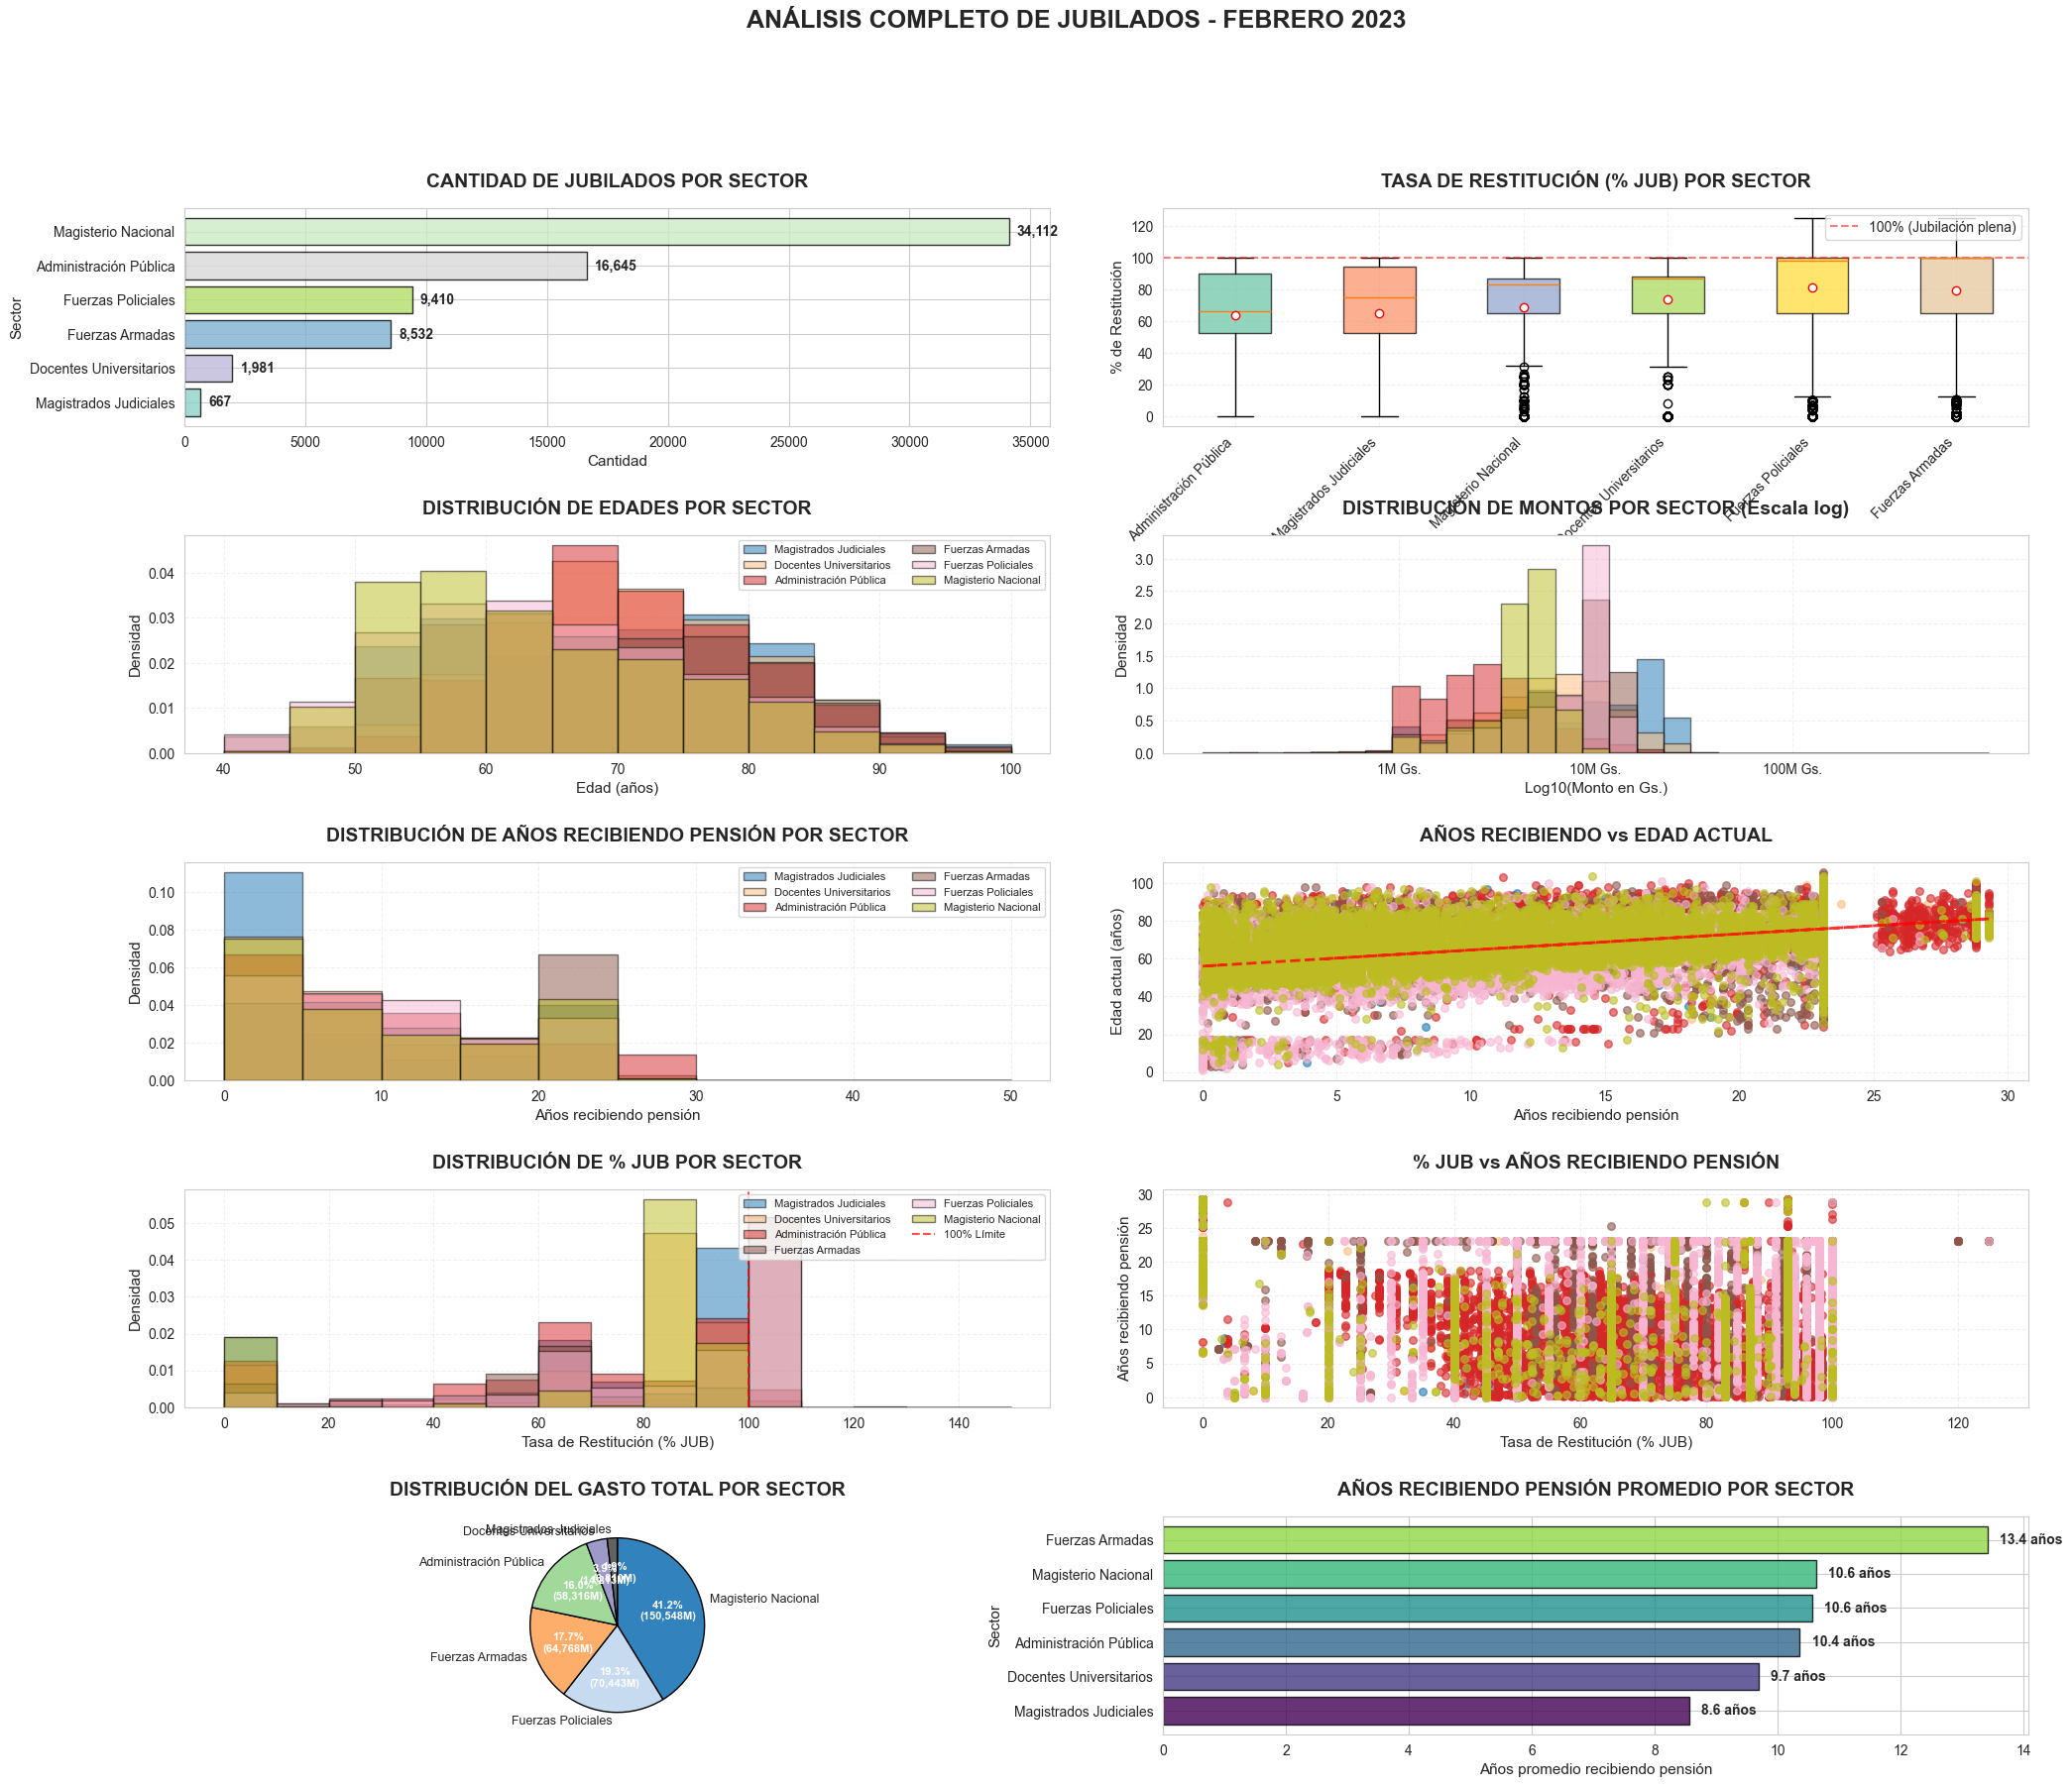


ANÁLISIS DETALLADO DE FECHA DE INGRESO (F_INGRESO) POR SECTOR

------------------------------------------------------------------------------------------------------------------------
SECTOR                     PROM_AÑOS    MEDIANA      MIN      MAX   <5AÑOS  5-10AÑOS  >20AÑOS
------------------------------------------------------------------------------------------------------------------------
Administración Pública          10.4        8.1      0.0     29.3    33.3%     22.9%    16.2%
Docentes Universitarios          9.7        6.7      0.0     29.3    38.0%     23.5%    17.8%
Fuerzas Armadas                 13.4       13.1      0.0     29.3    20.6%     20.7%    33.6%
Fuerzas Policiales              10.6        9.6      0.0     28.8    27.7%     23.2%    16.7%
Magisterio Nacional             10.6        7.8      0.0     29.3    37.5%     18.8%    21.8%
Magistrados Judiciales           8.6        4.5      0.0     29.3    55.2%     12.3%    20.4%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [16, 12]
plt.rcParams['font.size'] = 10

# ============================================================================
# 1. CARGA RÁPIDA DE DATOS
# ============================================================================

print("="*90)
print("ANÁLISIS COMPLETO - INCLUYENDO F_INGRESO Y HISTOGRAMAS POR SECTOR")
print("="*90)

# Cargar datos
file_path = 'D:\ArchivosHDD\GitHub\jubilacionUNA\Datos\Bdd Jupe Jubilados Febrero 23.csv'

try:
    df = pd.read_csv(file_path, encoding='iso-8859-1', low_memory=False)
    print(f"✓ Datos cargados: {len(df):,} registros")
except Exception as e:
    print(f"✗ Error al cargar archivo: {e}")
    exit()

# Limpiar columnas
df.columns = [col.strip() for col in df.columns]

# ============================================================================
# 2. PREPARAR DATOS CLAVE (CON MANEJO DE ERRORES)
# ============================================================================

# Mapeo de sectores
sector_map = {
    821: "Administración Pública",
    822: "Magistrados Judiciales", 
    823: "Magisterio Nacional",
    824: "Docentes Universitarios",
    825: "Fuerzas Armadas",
    826: "Fuerzas Policiales"
}

# Función para limpiar montos
def limpiar_monto(valor):
    try:
        if pd.isna(valor):
            return np.nan
        if isinstance(valor, str):
            return float(str(valor).strip().replace(' ', '').replace(',', ''))
        return float(valor)
    except:
        return np.nan

# Función para limpiar porcentajes
def limpiar_porcentaje(valor, debug=False):
    """
    Limpia valores de porcentaje con detección automática de formato
    """
    try:
        if pd.isna(valor):
            return np.nan
        
        original = str(valor)
        str_valor = original.strip()
        
        if debug:
            print(f"  Limpiando: '{original}' -> '{str_valor}'")
        
        # Caso 1: Vacío
        if not str_valor:
            return np.nan
        
        # Remover símbolos comunes
        str_valor = str_valor.replace('%', '')
        str_valor = str_valor.replace(' ', '')
        
        # Reemplazar coma por punto
        str_valor = str_valor.replace(',', '.')
        
        # Intentar convertir
        num_valor = float(str_valor)
        
        # DETECCIÓN DE FORMATO
        # Regla 1: Si el valor original tenía %, ya es porcentaje
        if '%' in original:
            return num_valor
        
        # Regla 2: Si está entre 0 y 1, probablemente es decimal
        if 0 <= num_valor <= 1:
            return num_valor * 100
        
        # Regla 3: Si está entre 1 y 2, podría ser decimal o porcentaje bajo
        if 1 < num_valor <= 2:
            # Verificar si es común en el contexto (ej: 1.5 = 150%)
            # En jubilaciones, raro tener 1.5% pero común 150%
            return num_valor * 100  # Asumir decimal
        
        # Regla 4: Si está entre 2 y 100, podría ser porcentaje o decimal raro
        if 2 < num_valor < 100:
            # Verificar patrones comunes
            if '.' in str_valor:  # Si tiene punto decimal
                # Ej: 83.5 podría ser 83.5% o 0.835
                # En jubilaciones, más probable porcentaje
                return num_valor
            else:
                # Entero, probablemente porcentaje
                return num_valor
        
        # Regla 5: Si es >= 100, casi seguro es porcentaje
        if num_valor >= 100:
            return num_valor
        
        # Caso por defecto
        return num_valor
        
    except Exception as e:
        if debug:
            print(f"❌ Error: {e}")
        return np.nan

print("\n🔍 PREPARANDO DATOS...")
print("-"*50)
print(df.columns)

# Aplicar transformaciones
transformaciones = []

if 'OBJ_CODIGO' in df.columns:
    df['SECTOR'] = df['OBJ_CODIGO'].map(sector_map)
    transformaciones.append("Sectores mapeados")

if 'MONTO_MENSUAL' in df.columns:
    df['MONTO'] = df['MONTO_MENSUAL'].apply(limpiar_monto)
    transformaciones.append("Montos limpiados")

if 'F_NACIM.' in df.columns:
    df['F_NACIM.'] = pd.to_datetime(df['F_NACIM.'], errors='coerce', dayfirst=True)
    # Calcular edad evitando NaN
    df['EDAD'] = ((pd.to_datetime('2023-02-28') - df['F_NACIM.']).dt.days / 365.25)
    # Convertir a int solo donde no hay NaN
    mask = df['EDAD'].notna()
    df.loc[mask, 'EDAD'] = df.loc[mask, 'EDAD'].astype(int)
    transformaciones.append("Edades calculadas")

# ============================================================================
# NUEVO: PROCESAR F_INGRESO
# ============================================================================
if 'F_INGRESO' in df.columns:
    df['F_INGRESO'] = pd.to_datetime(df['F_INGRESO'], errors='coerce', dayfirst=True)
    
    # Calcular años recibiendo pensión (hasta feb 2023)
    fecha_referencia = pd.to_datetime('2023-02-28')
    df['ANOS_RECIBIENDO'] = ((fecha_referencia - df['F_INGRESO']).dt.days / 365.25)
    mask = df['ANOS_RECIBIENDO'].notna()
    df.loc[mask, 'ANOS_RECIBIENDO'] = df.loc[mask, 'ANOS_RECIBIENDO'].round(1)
    
    transformaciones.append("F_INGRESO procesado - Años recibiendo calculados")
    
    # Calcular edad al momento de jubilarse
    if 'EDAD' in df.columns and 'ANOS_RECIBIENDO' in df.columns:
        df['EDAD_JUBILACION'] = df['EDAD'] - df['ANOS_RECIBIENDO']
        transformaciones.append("Edad al jubilarse calculada")

if len(df.columns) > 9:
    # Acceder por posición
    col_name = df.columns[9]
    print(f"\nColumna en posición 9: '{col_name}'")
    
    # Crear nueva columna limpia
    df['ANOS_APORTE'] = pd.to_numeric(df[col_name], errors='coerce')
    print(f"✓ 'ANOS_APORTE' creada a partir de columna '{col_name}'")

if 'AÑOS APORTE' in df.columns:
    df['ANOS_APORTE'] = pd.to_numeric(df['AÑOS APORTE'], errors='coerce')
    transformaciones.append("Años de aporte convertidos")

# IMPORTANTE: Limpiar columna % JUB
if 'PORC_JUBb' in df.columns:
    df['PORC_JUB'] = df['PORC_JUBb'].apply(limpiar_porcentaje)
    flag = df['PORC_JUB'] > 100
    print(df[flag][['CEDULA','PORC_JUBb','PORC_JUB'] ])
    transformaciones.append("% JUB (tasa restitución) limpiado")
    
# Filtrar solo filas con sector válido
if 'SECTOR' in df.columns:
    df = df[df['SECTOR'].notna()]
    transformaciones.append(f"Datos filtrados con sector válido: {len(df):,} registros")

# Mostrar resumen de transformaciones
for t in transformaciones:
    print(f"✓ {t}")

# ============================================================================
# 3. ANÁLISIS POR SECTOR (INCLUYENDO % JUB Y F_INGRESO)
# ============================================================================

print("\n" + "="*90)
print("RESUMEN PARA SIMULACIONES ACTUARIALES")
print("="*90)

if 'SECTOR' in df.columns:
    print("\n🔍 ANÁLISIS DE DISTRIBUCIONES POR SECTOR")
    print("-"*90)
    
    # Lista de sectores
    sectores = sorted(df['SECTOR'].unique())
    
    for sector in sectores:
        sector_data = df[df['SECTOR'] == sector]
        
        print(f"\n📊 {sector.upper()}:")
        print("-"*50)
        
        # ============================================================
        # 1. ESTADÍSTICOS DE EDAD (distribución probablemente bimodal)
        # ============================================================
        if 'EDAD' in sector_data.columns:
            edades = sector_data['EDAD'].dropna()
            print(f"EDAD (n={len(edades):,}):")
            
            # Estadísticos robustos
            stats_edad = {
                'media': edades.mean(),
                'mediana': edades.median(),
                'moda': edades.mode().iloc[0] if not edades.mode().empty else np.nan,
                'desv_std': edades.std(),
                'q1': edades.quantile(0.25),
                'q3': edades.quantile(0.75),
                'iqr': edades.quantile(0.75) - edades.quantile(0.25),
                'min': edades.min(),
                'max': edades.max(),
                'asimetria': edades.skew(),
                'curtosis': edades.kurtosis()
            }
            
            # Interpretar asimetría
            if stats_edad['asimetria'] > 0.5:
                forma = "↗️ Asimétrica positiva (más jóvenes)"
            elif stats_edad['asimetria'] < -0.5:
                forma = "↙️ Asimétrica negativa (más viejos)"
            else:
                forma = "↔️ Casi simétrica"
            
            # Interpretar curtosis
            if stats_edad['curtosis'] > 1:
                pico = "🔺 Leptocúrtica (pico alto)"
            elif stats_edad['curtosis'] < -1:
                pico = "🔻 Platicúrtica (plana)"
            else:
                pico = "⏺️  Mesocúrtica (normal)"
            
            print(f"  • Forma: {forma} (skew={stats_edad['asimetria']:.2f})")
            print(f"  • Pico: {pico} (kurt={stats_edad['curtosis']:.2f})")
            print(f"  • Centralidad: μ={stats_edad['media']:.1f}, M={stats_edad['mediana']:.1f}")
            print(f"  • Dispersión: σ={stats_edad['desv_std']:.1f}, IQR={stats_edad['iqr']:.1f}")
            print(f"  • Rango: [{stats_edad['min']:.0f}, {stats_edad['max']:.0f}]")
            print(f"  • Cuartiles: Q1={stats_edad['q1']:.1f}, Q2={stats_edad['mediana']:.1f}, Q3={stats_edad['q3']:.1f}")
            
            # Sugerir distribución
            if abs(stats_edad['asimetria']) > 1:
                print(f"  🎯 Distribución sugerida: Gamma o Weibull")
            elif stats_edad['curtosis'] > 2:
                print(f"  🎯 Distribución sugerida: t-Student o Log-normal")
            else:
                print(f"  🎯 Distribución sugerida: Normal truncada")
        
        # ============================================================
        # 2. ESTADÍSTICOS DE MONTO (distribución típicamente log-normal)
        # ============================================================
        if 'MONTO' in sector_data.columns:
            montos = sector_data['MONTO'].dropna()
            print(f"\nMONTO (n={len(montos):,}):")
            
            # Estadísticos en escala logarítmica
            montos_log = np.log(montos + 1)  # +1 para evitar log(0)
            
            stats_monto = {
                'media_arit': montos.mean(),
                'media_geom': np.exp(montos_log.mean()),
                'mediana': montos.median(),
                'desv_std': montos.std(),
                'cv': (montos.std() / montos.mean()) * 100 if montos.mean() > 0 else 0,
                'min': montos.min(),
                'max': montos.max(),
                'q1': montos.quantile(0.25),
                'q3': montos.quantile(0.75),
                'log_mean': montos_log.mean(),
                'log_std': montos_log.std()
            }
            
            # Coeficiente de variación (CV) para ver dispersión relativa
            if stats_monto['cv'] > 100:
                dispersion = "📈 MUY ALTA variabilidad"
            elif stats_monto['cv'] > 50:
                dispersion = "📈 Alta variabilidad"
            elif stats_monto['cv'] > 20:
                dispersion = "↗️ Moderada variabilidad"
            else:
                dispersion = "↔️ Baja variabilidad"
            
            print(f"  • Dispersión: {dispersion} (CV={stats_monto['cv']:.1f}%)")
            print(f"  • Centralidad: Media={stats_monto['media_arit']/1_000_000:.1f}M, "
                  f"Mediana={stats_monto['mediana']/1_000_000:.1f}M")
            print(f"  • Media geométrica: {stats_monto['media_geom']/1_000_000:.1f}M")
            print(f"  • Rango: [{stats_monto['min']/1_000_000:.1f}M, {stats_monto['max']/1_000_000:.1f}M]")
            print(f"  • Parámetros Log-normal: μ_log={stats_monto['log_mean']:.2f}, σ_log={stats_monto['log_std']:.2f}")
            
            # Verificar si es log-normal
            from scipy import stats
            _, p_value = stats.kstest((montos_log - montos_log.mean())/montos_log.std(), 'norm')
            
            if p_value > 0.05:
                print(f"  ✅ Pasa test de normalidad en log-scale (p={p_value:.3f})")
                print(f"  🎯 Distribución sugerida: Log-normal")
            else:
                print(f"  ⚠️ No pasa test de normalidad en log-scale (p={p_value:.3f})")
                print(f"  🎯 Distribución sugerida: Pareto o Gamma")
        
        # ============================================================
        # 3. ESTADÍSTICOS DE % JUB (distribución acotada 0-100%)
        # ============================================================
        if 'PORC_JUB' in sector_data.columns:
            porc_jub = sector_data['PORC_JUB'].dropna()
            print(f"\n% JUB (n={len(porc_jub):,}):")
            
            # Para porcentajes, distribución Beta es apropiada
            # Normalizar a 0-1
            porc_norm = porc_jub / 100
            
            stats_porc = {
                'media': porc_jub.mean(),
                'mediana': porc_jub.median(),
                'desv_std': porc_jub.std(),
                'min': porc_jub.min(),
                'max': porc_jub.max(),
                'alpha': 0,  # Parámetro Beta α
                'beta': 0    # Parámetro Beta β
            }
            
            # Calcular parámetros Beta (método de momentos)
            mean_norm = porc_norm.mean()
            var_norm = porc_norm.var()
            
            if var_norm > 0:
                alpha = mean_norm * (mean_norm * (1 - mean_norm) / var_norm - 1)
                beta = (1 - mean_norm) * (mean_norm * (1 - mean_norm) / var_norm - 1)
                stats_porc['alpha'] = alpha
                stats_porc['beta'] = beta
            
            print(f"  • Centralidad: {stats_porc['media']:.1f}% (mediana: {stats_porc['mediana']:.1f}%)")
            print(f"  • Rango: [{stats_porc['min']:.1f}%, {stats_porc['max']:.1f}%]")
            print(f"  • Dispersión: σ={stats_porc['desv_std']:.1f}%")
            
            if stats_porc['alpha'] > 0 and stats_porc['beta'] > 0:
                print(f"  • Parámetros Beta: α={stats_porc['alpha']:.2f}, β={stats_porc['beta']:.2f}")
                print(f"  🎯 Distribución sugerida: Beta(α={stats_porc['alpha']:.2f}, β={stats_porc['beta']:.2f})")
            else:
                print(f"  🎯 Distribución sugerida: Triangular o Uniforme truncada")
        
        # ============================================================
        # 4. AÑOS RECIBIENDO (distribución típicamente exponencial)
        # ============================================================
        if 'ANOS_RECIBIENDO' in sector_data.columns:
            anos_rec = sector_data['ANOS_RECIBIENDO'].dropna()
            print(f"\nAÑOS RECIBIENDO (n={len(anos_rec):,}):")
            
            stats_anos = {
                'media': anos_rec.mean(),
                'mediana': anos_rec.median(),
                'desv_std': anos_rec.std(),
                'lambda_exp': 1 / anos_rec.mean() if anos_rec.mean() > 0 else 0,
                'min': anos_rec.min(),
                'max': anos_rec.max()
            }
            
            # Verificar si sigue distribución exponencial
            # (tiempos de supervivencia típicamente exponenciales)
            cv = anos_rec.std() / anos_rec.mean() if anos_rec.mean() > 0 else 0
            
            if 0.9 < cv < 1.1:
                print(f"  ✅ Coeficiente de variación ~1 (CV={cv:.2f}) → Distribución exponencial")
                print(f"  • Parámetro λ={stats_anos['lambda_exp']:.3f}")
                print(f"  🎯 Distribución sugerida: Exponencial(λ={stats_anos['lambda_exp']:.3f})")
            else:
                print(f"  ⚠️ CV={cv:.2f} (no es 1)")
                print(f"  • Media={stats_anos['media']:.1f}años, Mediana={stats_anos['mediana']:.1f}años")
                print(f"  🎯 Distribución sugerida: Weibull o Gamma")

# ============================================================================
# RESUMEN COMPACTO PARA SIMULACIÓN
# ============================================================================

print("\n" + "="*90)
print("🎯 PARÁMETROS PARA SIMULACIÓN MONTE CARLO")
print("="*90)

if 'SECTOR' in df.columns:
    print("\n" + "-"*120)
    print(f"{'SECTOR':<20} {'EDAD':<25} {'MONTO':<25} {'%JUB':<20} {'AÑOS_REC':<20}")
    print("-"*120)
    
    for sector in sectores:
        sector_data = df[df['SECTOR'] == sector]
        
        # EDAD: Distribución más apropiada
        if 'EDAD' in sector_data.columns:
            edades = sector_data['EDAD'].dropna()
            skew = edades.skew()
            
            if abs(skew) > 1:
                # Distribución sesgada → Gamma
                # Método de momentos para Gamma
                mean_e = edades.mean()
                var_e = edades.var()
                k = (mean_e ** 2) / var_e if var_e > 0 else 1
                theta = var_e / mean_e if mean_e > 0 else 1
                edad_dist = f"Gamma(k={k:.1f}, θ={theta:.1f})"
            else:
                # Casi simétrica → Normal truncada
                edad_dist = f"N({edades.mean():.1f}, {edades.std():.1f})[{edades.min():.0f},{edades.max():.0f}]"
        else:
            edad_dist = "N/A"
        
        # MONTO: Log-normal
        if 'MONTO' in sector_data.columns:
            montos = sector_data['MONTO'].dropna()
            montos_log = np.log(montos + 1)
            monto_dist = f"LogN(μ={montos_log.mean():.2f}, σ={montos_log.std():.2f})"
        else:
            monto_dist = "N/A"
        
        # %JUB: Beta (acotada 0-100%)
        if 'PORC_JUB' in sector_data.columns:
            porc = sector_data['PORC_JUB'].dropna()
            porc_norm = porc / 100
            mean_p = porc_norm.mean()
            var_p = porc_norm.var()
            
            if var_p > 0:
                alpha = mean_p * (mean_p * (1 - mean_p) / var_p - 1)
                beta = (1 - mean_p) * (mean_p * (1 - mean_p) / var_p - 1)
                if alpha > 0 and beta > 0:
                    jub_dist = f"Beta(α={alpha:.1f}, β={beta:.1f})×100"
                else:
                    jub_dist = f"U({porc.min():.1f}%,{porc.max():.1f}%)"
            else:
                jub_dist = f"{porc.mean():.1f}%"
        else:
            jub_dist = "N/A"
        
        # AÑOS RECIBIENDO: Exponencial o Weibull
        if 'ANOS_RECIBIENDO' in sector_data.columns:
            anos = sector_data['ANOS_RECIBIENDO'].dropna()
            cv = anos.std() / anos.mean() if anos.mean() > 0 else 0
            
            if 0.8 < cv < 1.2:
                # Cercano a 1 → Exponencial
                lam = 1 / anos.mean() if anos.mean() > 0 else 0
                anos_dist = f"Exp(λ={lam:.3f})"
            else:
                # Otra distribución → Weibull
                from scipy import stats
                try:
                    params = stats.weibull_min.fit(anos, floc=0)
                    anos_dist = f"Weibull(c={params[0]:.2f}, scale={params[2]:.1f})"
                except:
                    anos_dist = f"Empírica(μ={anos.mean():.1f})"
        else:
            anos_dist = "N/A"
        
        print(f"{sector[:19]:<20} {edad_dist:<25} {monto_dist:<25} {jub_dist:<20} {anos_dist:<20}")

print("\n" + "="*90)
print("📝 RECOMENDACIONES DE SIMULACIÓN:")
print("="*90)
print("1. EDAD: Usar Gamma o Normal truncada (según asimetría)")
print("2. MONTO: Siempre Log-normal (sesgo positivo inherente)")
print("3. %JUB: Beta para porcentajes acotados")
print("4. AÑOS_RECIBIENDO: Exponencial para tiempos de supervivencia")
print("5. CORRELACIONES: Verificar correlación edad-monto y edad-%jub")
print("="*90)
# ============================================================================
# 4. GRÁFICOS DE DISTRIBUCIÓN (INCLUYENDO HISTOGRAMAS POR SECTOR)
# ============================================================================

print("\n" + "="*90)
print("GENERANDO GRÁFICOS DE DISTRIBUCIÓN CON HISTOGRAMAS POR SECTOR")
print("="*90)

# Crear figura grande - MÁS GRANDE PARA INCLUIR HISTOGRAMAS
fig = plt.figure(figsize=(24, 20))
fig.suptitle('ANÁLISIS COMPLETO DE JUBILADOS - FEBRERO 2023', 
             fontsize=18, fontweight='bold', y=0.98)

# Definir layout de subplots (5x4 para incluir histogramas)
gs = fig.add_gridspec(5, 4, hspace=0.5, wspace=0.3)

# 1. DISTRIBUCIÓN POR CANTIDAD (BAR PLOT)
ax1 = fig.add_subplot(gs[0, 0:2])
if 'SECTOR' in df.columns:
    sector_counts = df['SECTOR'].value_counts().sort_values(ascending=True)
    colors = plt.cm.Set3(np.arange(len(sector_counts)) / len(sector_counts))
    bars = ax1.barh(range(len(sector_counts)), sector_counts.values, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_title('CANTIDAD DE JUBILADOS POR SECTOR', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Cantidad', fontsize=11)
    ax1.set_ylabel('Sector', fontsize=11)
    ax1.set_yticks(range(len(sector_counts)))
    ax1.set_yticklabels(sector_counts.index, fontsize=10)
    
    # Agregar valores
    for i, (bar, v) in enumerate(zip(bars, sector_counts.values)):
        width = bar.get_width()
        ax1.text(width + max(sector_counts.values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:,}', ha='left', va='center', fontsize=10, fontweight='bold')

# 2. DISTRIBUCIÓN DE % JUB POR SECTOR (BOX PLOT)
ax2 = fig.add_subplot(gs[0, 2:])
if 'SECTOR' in df.columns and 'PORC_JUB' in df.columns:
    sectores_orden = df.groupby('SECTOR')['PORC_JUB'].median().sort_values().index
    box_data = [df[df['SECTOR'] == sector]['PORC_JUB'].dropna() for sector in sectores_orden]
    
    bp = ax2.boxplot(box_data, labels=sectores_orden, patch_artist=True, showmeans=True,
                    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'red'})
    
    colors_box = plt.cm.Set2(np.arange(len(sectores_orden)) / len(sectores_orden))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_title('TASA DE RESTITUCIÓN (% JUB) POR SECTOR', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Sector', fontsize=11)
    ax2.set_ylabel('% de Restitución', fontsize=11)
    ax2.tick_params(axis='x', labelsize=10)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% (Jubilación plena)')
    ax2.legend(loc='upper right')

# 3. HISTOGRAMAS POR SECTOR: EDAD
ax3 = fig.add_subplot(gs[1, 0:2])
if 'SECTOR' in df.columns and 'EDAD' in df.columns:
    sectores = df['SECTOR'].unique()
    colors = plt.cm.tab20(np.arange(len(sectores)) / len(sectores))
    
    # Configurar bins
    bins_edad = np.arange(40, 101, 5)
    
    # Graficar histogramas superpuestos
    for i, sector in enumerate(sectores):
        sector_data = df[df['SECTOR'] == sector]['EDAD'].dropna()
        ax3.hist(sector_data, bins=bins_edad, alpha=0.5, label=sector, 
                color=colors[i], density=True, edgecolor='black')
    
    ax3.set_title('DISTRIBUCIÓN DE EDADES POR SECTOR', fontsize=14, fontweight='bold', pad=15)
    ax3.set_xlabel('Edad (años)', fontsize=11)
    ax3.set_ylabel('Densidad', fontsize=11)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.legend(fontsize=8, loc='upper right', ncol=2)

# 4. HISTOGRAMAS POR SECTOR: MONTO
ax4 = fig.add_subplot(gs[1, 2:])
if 'SECTOR' in df.columns and 'MONTO' in df.columns:
    sectores = df['SECTOR'].unique()
    colors = plt.cm.tab20(np.arange(len(sectores)) / len(sectores))
    
    # Usar escala logarítmica para montos
    df['MONTO_LOG'] = np.log10(df['MONTO'] + 1)
    
    # Configurar bins
    bins_monto = np.linspace(5, 9, 30)  # Log scale: 100,000 a 1,000,000,000
    
    # Graficar histogramas superpuestos
    for i, sector in enumerate(sectores):
        sector_data = df[df['SECTOR'] == sector]['MONTO_LOG'].dropna()
        ax4.hist(sector_data, bins=bins_monto, alpha=0.5, label=sector, 
                color=colors[i], density=True, edgecolor='black')
    
    ax4.set_title('DISTRIBUCIÓN DE MONTOS POR SECTOR (Escala log)', fontsize=14, fontweight='bold', pad=15)
    ax4.set_xlabel('Log10(Monto en Gs.)', fontsize=11)
    ax4.set_ylabel('Densidad', fontsize=11)
    ax4.grid(True, alpha=0.3, linestyle='--')
    
    # Convertir ticks a valores comprensibles
    ticks = [6, 7, 8]  # 1M, 10M, 100M
    tick_labels = ['1M Gs.', '10M Gs.', '100M Gs.']
    ax4.set_xticks(ticks)
    ax4.set_xticklabels(tick_labels)

# 5. NUEVO: HISTOGRAMAS POR SECTOR: AÑOS RECIBIENDO (F_INGRESO)
ax5 = fig.add_subplot(gs[2, 0:2])
if 'SECTOR' in df.columns and 'ANOS_RECIBIENDO' in df.columns:
    sectores = df['SECTOR'].unique()
    colors = plt.cm.tab20(np.arange(len(sectores)) / len(sectores))
    
    # Configurar bins
    bins_anos = np.arange(0, 51, 5)
    
    # Graficar histogramas superpuestos
    for i, sector in enumerate(sectores):
        sector_data = df[df['SECTOR'] == sector]['ANOS_RECIBIENDO'].dropna()
        ax5.hist(sector_data, bins=bins_anos, alpha=0.5, label=sector, 
                color=colors[i], density=True, edgecolor='black')
    
    ax5.set_title('DISTRIBUCIÓN DE AÑOS RECIBIENDO PENSIÓN POR SECTOR', fontsize=14, fontweight='bold', pad=15)
    ax5.set_xlabel('Años recibiendo pensión', fontsize=11)
    ax5.set_ylabel('Densidad', fontsize=11)
    ax5.grid(True, alpha=0.3, linestyle='--')
    ax5.legend(fontsize=8, loc='upper right', ncol=2)

# 6. SCATTER PLOT: AÑOS RECIBIENDO vs EDAD
ax6 = fig.add_subplot(gs[2, 2:])
if all(col in df.columns for col in ['ANOS_RECIBIENDO', 'EDAD', 'SECTOR']):
    # Crear colores por sector
    sectores = df['SECTOR'].unique()
    color_map = {sector: plt.cm.tab20(i/len(sectores)) for i, sector in enumerate(sectores)}
    
    # Graficar por sector
    for sector in sectores:
        mask = df['SECTOR'] == sector
        subset = df[mask].dropna(subset=['ANOS_RECIBIENDO', 'EDAD'])
        if len(subset) > 0:
            ax6.scatter(subset['ANOS_RECIBIENDO'], subset['EDAD'], 
                       alpha=0.6, s=30, label=sector, color=color_map[sector])
    
    ax6.set_title('AÑOS RECIBIENDO vs EDAD ACTUAL', fontsize=14, fontweight='bold', pad=15)
    ax6.set_xlabel('Años recibiendo pensión', fontsize=11)
    ax6.set_ylabel('Edad actual (años)', fontsize=11)
    ax6.grid(True, alpha=0.3, linestyle='--')
    
    # Línea de regresión
    if len(subset) > 1:
        x = df['ANOS_RECIBIENDO'].dropna()
        y = df['EDAD'].dropna()
        if len(x) > 0 and len(y) > 0:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            ax6.plot(x, p(x), "r--", alpha=0.8, linewidth=2, label='Tendencia')

# 7. HISTOGRAMAS POR SECTOR: % JUB
ax7 = fig.add_subplot(gs[3, 0:2])
if 'SECTOR' in df.columns and 'PORC_JUB' in df.columns:
    sectores = df['SECTOR'].unique()
    colors = plt.cm.tab20(np.arange(len(sectores)) / len(sectores))
    
    # Configurar bins
    bins_porc = np.arange(0, 151, 10)
    
    # Graficar histogramas superpuestos
    for i, sector in enumerate(sectores):
        sector_data = df[df['SECTOR'] == sector]['PORC_JUB'].dropna()
        ax7.hist(sector_data, bins=bins_porc, alpha=0.5, label=sector, 
                color=colors[i], density=True, edgecolor='black')
    
    ax7.set_title('DISTRIBUCIÓN DE % JUB POR SECTOR', fontsize=14, fontweight='bold', pad=15)
    ax7.set_xlabel('Tasa de Restitución (% JUB)', fontsize=11)
    ax7.set_ylabel('Densidad', fontsize=11)
    ax7.grid(True, alpha=0.3, linestyle='--')
    ax7.axvline(x=100, color='red', linestyle='--', alpha=0.7, label='100% Límite')
    ax7.legend(fontsize=8, loc='upper right', ncol=2)

# 8. SCATTER PLOT: % JUB vs AÑOS RECIBIENDO
ax8 = fig.add_subplot(gs[3, 2:])
if all(col in df.columns for col in ['PORC_JUB', 'ANOS_RECIBIENDO', 'SECTOR']):
    # Graficar por sector
    for sector in sectores:
        mask = df['SECTOR'] == sector
        subset = df[mask].dropna(subset=['PORC_JUB', 'ANOS_RECIBIENDO'])
        if len(subset) > 0:
            ax8.scatter(subset['PORC_JUB'], subset['ANOS_RECIBIENDO'], 
                       alpha=0.6, s=30, label=sector, color=color_map[sector])
    
    ax8.set_title('% JUB vs AÑOS RECIBIENDO PENSIÓN', fontsize=14, fontweight='bold', pad=15)
    ax8.set_xlabel('Tasa de Restitución (% JUB)', fontsize=11)
    ax8.set_ylabel('Años recibiendo pensión', fontsize=11)
    ax8.grid(True, alpha=0.3, linestyle='--')

# 9. GRÁFICO DE TORTA - DISTRIBUCIÓN DEL GASTO POR SECTOR
ax9 = fig.add_subplot(gs[4, 0:2])
if 'SECTOR' in df.columns and 'MONTO' in df.columns:
    gasto_por_sector = df.groupby('SECTOR')['MONTO'].sum()
    gasto_por_sector = gasto_por_sector.sort_values(ascending=False)
    
    # Convertir a millones
    gasto_mill = gasto_por_sector / 1_000_000
    
    colors_pie = plt.cm.tab20c(np.arange(len(gasto_mill)) / len(gasto_mill))
    wedges, texts, autotexts = ax9.pie(gasto_mill.values, labels=gasto_mill.index, 
                                       autopct=lambda pct: f'{pct:.1f}%\n({pct*sum(gasto_mill.values)/100:,.0f}M)',
                                       colors=colors_pie, startangle=90, 
                                       counterclock=False, textprops={'fontsize': 9},
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 1})
    
    ax9.set_title('DISTRIBUCIÓN DEL GASTO TOTAL POR SECTOR', fontsize=14, fontweight='bold', pad=15)
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)

# 10. GRÁFICO DE BARRAS: AÑOS RECIBIENDO PROMEDIO POR SECTOR
ax10 = fig.add_subplot(gs[4, 2:])
if 'SECTOR' in df.columns and 'ANOS_RECIBIENDO' in df.columns:
    anos_promedio = df.groupby('SECTOR')['ANOS_RECIBIENDO'].mean().sort_values(ascending=True)
    
    colors_bar = plt.cm.viridis(np.arange(len(anos_promedio)) / len(anos_promedio))
    bars = ax10.barh(range(len(anos_promedio)), anos_promedio.values, color=colors_bar, edgecolor='black', alpha=0.8)
    
    ax10.set_title('AÑOS RECIBIENDO PENSIÓN PROMEDIO POR SECTOR', fontsize=14, fontweight='bold', pad=15)
    ax10.set_xlabel('Años promedio recibiendo pensión', fontsize=11)
    ax10.set_ylabel('Sector', fontsize=11)
    ax10.set_yticks(range(len(anos_promedio)))
    ax10.set_yticklabels(anos_promedio.index, fontsize=10)
    
    # Agregar valores
    for i, (bar, v) in enumerate(zip(bars, anos_promedio.values)):
        width = bar.get_width()
        ax10.text(width + 0.2, bar.get_y() + bar.get_height()/2,
                f'{v:.1f} años', ha='left', va='center', fontsize=10, fontweight='bold')

# Ajustar layout y guardar
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar gráfico
plt.savefig('analisis_completo_con_fingreso.png', dpi=150, bbox_inches='tight', facecolor='white')
print("\n✓ Gráfico guardado como: analisis_completo_con_fingreso.png")

# Mostrar gráfico
plt.show()

# ============================================================================
# 5. ANÁLISIS DETALLADO DE F_INGRESO POR SECTOR
# ============================================================================

print("\n" + "="*90)
print("ANÁLISIS DETALLADO DE FECHA DE INGRESO (F_INGRESO) POR SECTOR")
print("="*90)

if 'SECTOR' in df.columns and 'ANOS_RECIBIENDO' in df.columns:
    print("\n" + "-"*120)
    print(f"{'SECTOR':<25} {'PROM_AÑOS':>10} {'MEDIANA':>10} {'MIN':>8} {'MAX':>8} {'<5AÑOS':>8} {'5-10AÑOS':>9} {'>20AÑOS':>8}")
    print("-"*120)
    
    for sector in sorted(df['SECTOR'].dropna().unique()):
        sector_data = df[df['SECTOR'] == sector]
        anos_data = sector_data['ANOS_RECIBIENDO'].dropna()
        
        if len(anos_data) > 0:
            # Estadísticas
            promedio = anos_data.mean()
            mediana = anos_data.median()
            minimo = anos_data.min()
            maximo = anos_data.max()
            
            # Conteos por rangos
            menos_5 = ((anos_data < 5).sum() / len(anos_data) * 100)
            entre_5_10 = (((anos_data >= 5) & (anos_data < 10)).sum() / len(anos_data) * 100)
            mas_20 = ((anos_data >= 20).sum() / len(anos_data) * 100)
            
            print(f"{sector[:24]:<25} {promedio:>10.1f} {mediana:>10.1f} {minimo:>8.1f} {maximo:>8.1f} "
                  f"{menos_5:>7.1f}% {entre_5_10:>8.1f}% {mas_20:>7.1f}%")
        else:
            print(f"{sector[:24]:<25} {'SIN DATOS':>10} {'SIN DATOS':>10} {'SIN DATOS':>8} "
                  f"{'SIN DATOS':>8} {'SIN DATOS':>8} {'SIN DATOS':>9} {'SIN DATOS':>8}")

# Continuar con el resto del código original (secciones 6, 7, 8)...
# [El resto del código permanece igual desde aquí...]


📊 ANÁLISIS DE PERCENTILES POR SECTOR

📈 PERCENTILES DE MONTOS DE PENSIÓN POR SECTOR (en millones de Gs.)
------------------------------------------------------------------------------------------------------------------------

Administración Pública:
  N = 16,645 | Media = 3.5M | Mediana = 2.7M
  Percentiles:
    P   1% =      0.8M    P   5% =      1.0M    P  10% =      1.0M    P  25% =      1.7M
    P  50% =      2.7M    P  75% =      4.2M
    P  90% =      6.6M    P  95% =      9.5M    P  99% =     16.6M
Docentes Universitarios:
  N = 1,981 | Media = 7.2M | Mediana = 6.0M
  Percentiles:
    P   1% =      1.0M    P   5% =      1.3M    P  10% =      1.9M    P  25% =      3.3M
    P  50% =      6.0M    P  75% =      9.7M
    P  90% =     14.1M    P  95% =     17.1M    P  99% =     26.3M
Fuerzas Armadas:
  N = 8,532 | Media = 7.6M | Mediana = 8.4M
  Percentiles:
    P   1% =      1.0M    P   5% =      1.6M    P  10% =      2.4M    P  25% =      4.5M
    P  50% =      8.4M    P  75% =   

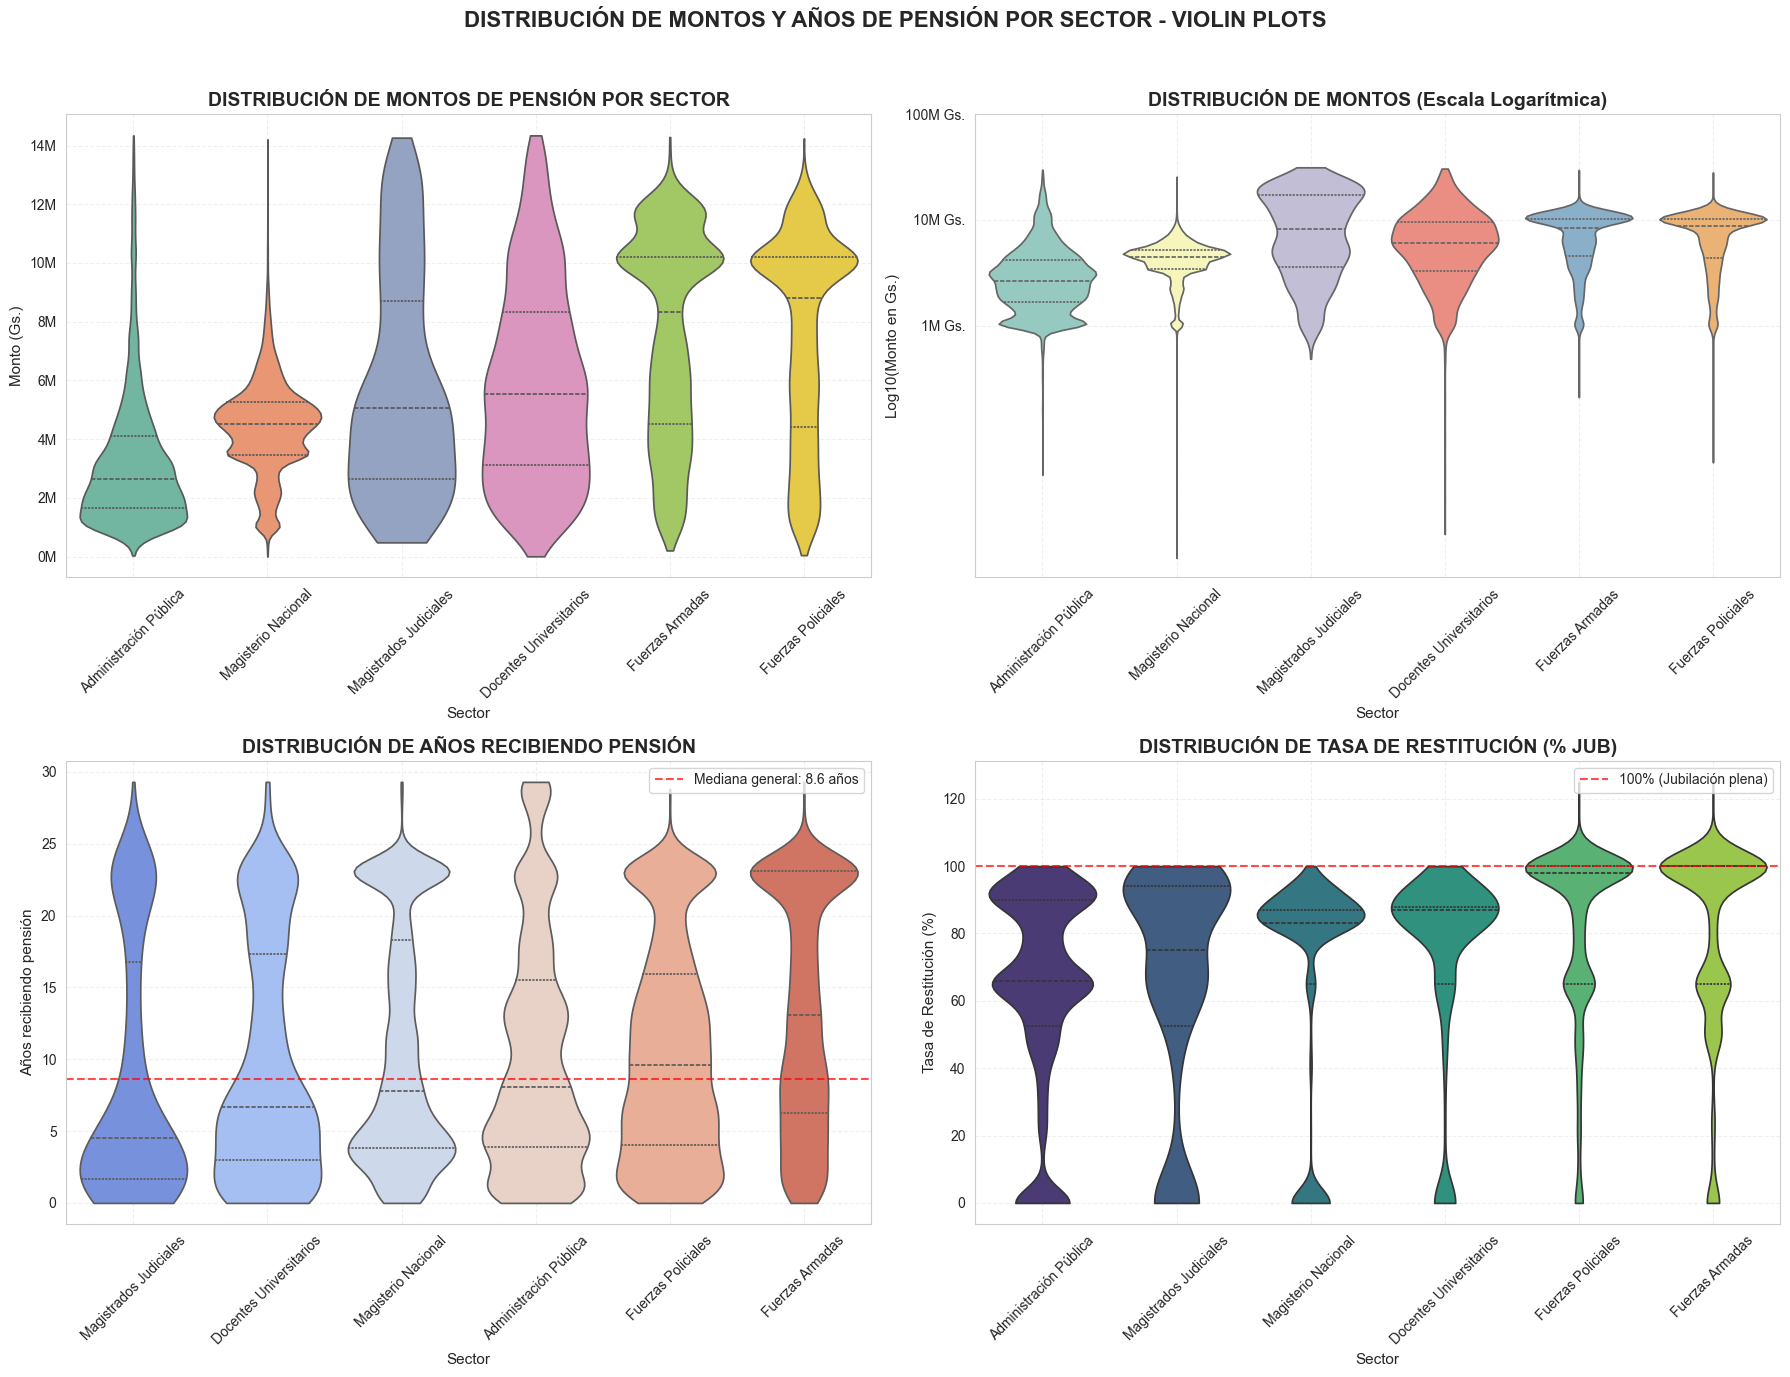


📋 TABLA RESUMEN DE PERCENTILES POR SECTOR

🎯 MONTOS DE PENSIÓN (en millones de Gs.):
------------------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------------------------------------------------
SECTOR                       N    MEDIA       P5      P25  MEDIANA      P75      P95      IQR    CV%
------------------------------------------------------------------------------------------------------------------------------------------------------
Administración Pública    16645      3.5      1.0      1.7      2.7      4.2      9.5      2.5   86.3
Docentes Universitarios   1981      7.2      1.3      3.3      6.0      9.7     17.1      6.3   72.0
Fuerzas Armadas           8532      7.6      1.6      4.5      8.4     10.2     11.7      5.7   46.6
Fuerzas Policiales        9410      7.5      1.3      4.4      8.9     10.2     11.7 

In [10]:
# ============================================================================
# 6. CÁLCULO DE PERCENTILES PARA MONTOS Y AÑOS RECIBIENDO
# ============================================================================

print("\n" + "="*90)
print("📊 ANÁLISIS DE PERCENTILES POR SECTOR")
print("="*90)

if 'SECTOR' in df.columns:
    # Definir percentiles a calcular
    percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    
    print("\n📈 PERCENTILES DE MONTOS DE PENSIÓN POR SECTOR (en millones de Gs.)")
    print("-"*120)
    
    # Calcular percentiles para montos por sector
    for sector in sorted(df['SECTOR'].unique()):
        sector_data = df[df['SECTOR'] == sector]
        montos = sector_data['MONTO'].dropna()
        
        if len(montos) > 0:
            # Calcular percentiles
            perc_values = montos.quantile(percentiles) / 1_000_000  # Convertir a millones
            
            print(f"\n{sector}:")
            print(f"  N = {len(montos):,} | Media = {montos.mean()/1_000_000:.1f}M | Mediana = {montos.median()/1_000_000:.1f}M")
            print("  Percentiles:")
            for p, v in zip(percentiles, perc_values):
                print(f"    P{p*100:4.0f}% = {v:8.1f}M", end="")
                if p in [0.25, 0.75]:
                    print()
    
    print("\n\n📈 PERCENTILES DE AÑOS RECIBIENDO PENSIÓN POR SECTOR")
    print("-"*120)
    
    # Calcular percentiles para años recibiendo por sector
    for sector in sorted(df['SECTOR'].unique()):
        sector_data = df[df['SECTOR'] == sector]
        anos_rec = sector_data['ANOS_RECIBIENDO'].dropna()
        
        if len(anos_rec) > 0:
            # Calcular percentiles
            perc_values = anos_rec.quantile(percentiles)
            
            print(f"\n{sector}:")
            print(f"  N = {len(anos_rec):,} | Media = {anos_rec.mean():.1f} años | Mediana = {anos_rec.median():.1f} años")
            print("  Percentiles:")
            for p, v in zip(percentiles, perc_values):
                print(f"    P{p*100:4.0f}% = {v:5.1f} años", end="")
                if p in [0.25, 0.75]:
                    print()

# ============================================================================
# 7. VIOLIN PLOTS PARA VISUALIZACIÓN DE DISTRIBUCIONES
# ============================================================================

print("\n" + "="*90)
print("🎻 GENERANDO VIOLIN PLOTS DE DISTRIBUCIÓN")
print("="*90)

# Crear figura para violin plots
fig_violin, axes_violin = plt.subplots(2, 2, figsize=(18, 14))
fig_violin.suptitle('DISTRIBUCIÓN DE MONTOS Y AÑOS DE PENSIÓN POR SECTOR - VIOLIN PLOTS', 
                   fontsize=16, fontweight='bold', y=0.98)

# 1. VIOLIN PLOT: MONTOS DE PENSIÓN POR SECTOR
ax1 = axes_violin[0, 0]
if 'SECTOR' in df.columns and 'MONTO' in df.columns:
    # Filtrar datos extremos para mejor visualización
    monto_q99 = df['MONTO'].quantile(0.99)
    df_filtered = df[df['MONTO'] <= monto_q99]
    
    # Ordenar sectores por mediana de montos
    sector_order = df_filtered.groupby('SECTOR')['MONTO'].median().sort_values().index
    
    # Crear violin plot
    sns.violinplot(data=df_filtered, x='SECTOR', y='MONTO', 
                   order=sector_order, ax=ax1, palette='Set2', 
                   inner='quartile', cut=0)
    
    ax1.set_title('DISTRIBUCIÓN DE MONTOS DE PENSIÓN POR SECTOR', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Sector', fontsize=11)
    ax1.set_ylabel('Monto (Gs.)', fontsize=11)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Formatear eje Y en millones
    yticks = ax1.get_yticks()
    ax1.set_yticklabels([f'{int(y/1_000_000):,}M' for y in yticks])

# 2. VIOLIN PLOT: MONTOS DE PENSIÓN (escala logarítmica)
ax2 = axes_violin[0, 1]
if 'SECTOR' in df.columns and 'MONTO' in df.columns:
    # Crear columna con log(monto)
    df_log = df.copy()
    df_log['LOG_MONTO'] = np.log10(df_log['MONTO'] + 1)
    
    # Crear violin plot en escala logarítmica
    sns.violinplot(data=df_log, x='SECTOR', y='LOG_MONTO', 
                   order=sector_order, ax=ax2, palette='Set3', 
                   inner='quartile', cut=0)
    
    ax2.set_title('DISTRIBUCIÓN DE MONTOS (Escala Logarítmica)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Sector', fontsize=11)
    ax2.set_ylabel('Log10(Monto en Gs.)', fontsize=11)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Convertir ticks a valores comprensibles
    ticks = [6, 7, 8]  # 1M, 10M, 100M
    tick_labels = ['1M Gs.', '10M Gs.', '100M Gs.']
    ax2.set_yticks(ticks)
    ax2.set_yticklabels(tick_labels)

# 3. VIOLIN PLOT: AÑOS RECIBIENDO PENSIÓN POR SECTOR
ax3 = axes_violin[1, 0]
if 'SECTOR' in df.columns and 'ANOS_RECIBIENDO' in df.columns:
    # Ordenar sectores por mediana de años
    sector_order_anos = df.groupby('SECTOR')['ANOS_RECIBIENDO'].median().sort_values().index
    
    # Crear violin plot
    sns.violinplot(data=df, x='SECTOR', y='ANOS_RECIBIENDO', 
                   order=sector_order_anos, ax=ax3, palette='coolwarm', 
                   inner='quartile', cut=0)
    
    ax3.set_title('DISTRIBUCIÓN DE AÑOS RECIBIENDO PENSIÓN', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Sector', fontsize=11)
    ax3.set_ylabel('Años recibiendo pensión', fontsize=11)
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, linestyle='--')
    
    # Agregar línea de mediana general
    mediana_total = df['ANOS_RECIBIENDO'].median()
    ax3.axhline(y=mediana_total, color='red', linestyle='--', alpha=0.7, 
               label=f'Mediana general: {mediana_total:.1f} años')
    ax3.legend(loc='upper right')

# 4. VIOLIN PLOT: % JUB POR SECTOR
ax4 = axes_violin[1, 1]
if 'SECTOR' in df.columns and 'PORC_JUB' in df.columns:
    # Ordenar sectores por mediana de % JUB
    sector_order_jub = df.groupby('SECTOR')['PORC_JUB'].median().sort_values().index
    
    # Crear violin plot
    sns.violinplot(data=df, x='SECTOR', y='PORC_JUB', 
                   order=sector_order_jub, ax=ax4, palette='viridis', 
                   inner='quartile', cut=0)
    
    ax4.set_title('DISTRIBUCIÓN DE TASA DE RESTITUCIÓN (% JUB)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Sector', fontsize=11)
    ax4.set_ylabel('Tasa de Restitución (%)', fontsize=11)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, linestyle='--')
    
    # Agregar línea de referencia al 100%
    ax4.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='100% (Jubilación plena)')
    ax4.legend(loc='upper right')

# Ajustar layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar gráfico de violin plots
plt.savefig('violin_plots_distribucion.png', dpi=150, bbox_inches='tight', facecolor='white')
print("\n✓ Violin plots guardados como: violin_plots_distribucion.png")

# Mostrar gráficos
plt.show()

# ============================================================================
# 8. TABLA RESUMEN DE PERCENTILES
# ============================================================================

print("\n" + "="*90)
print("📋 TABLA RESUMEN DE PERCENTILES POR SECTOR")
print("="*90)

if 'SECTOR' in df.columns:
    # Crear tabla resumen para montos
    print("\n🎯 MONTOS DE PENSIÓN (en millones de Gs.):")
    print("-"*120)
    
    # Definir percentiles clave
    perc_key = [0.05, 0.25, 0.50, 0.75, 0.95]
    perc_names = ['P5', 'P25', 'Mediana (P50)', 'P75', 'P95']
    
    resumen_data = []
    
    for sector in sorted(df['SECTOR'].unique()):
        sector_data = df[df['SECTOR'] == sector]
        montos = sector_data['MONTO'].dropna()
        anos = sector_data['ANOS_RECIBIENDO'].dropna()
        
        if len(montos) > 0 and len(anos) > 0:
            # Calcular percentiles para montos
            montos_perc = montos.quantile(perc_key) / 1_000_000
            
            # Calcular percentiles para años
            anos_perc = anos.quantile(perc_key)
            
            # Calcular estadísticas adicionales
            iqr_monto = montos_perc[0.75] - montos_perc[0.25]
            cv_monto = (montos.std() / montos.mean()) * 100
            
            iqr_anos = anos_perc[0.75] - anos_perc[0.25]
            cv_anos = (anos.std() / anos.mean()) * 100
            
            resumen_data.append({
                'SECTOR': sector,
                'N_MONTOS': len(montos),
                'MEDIA_MONTO': montos.mean() / 1_000_000,
                'P5_MONTO': montos_perc[0.05],
                'P25_MONTO': montos_perc[0.25],
                'MEDIANA_MONTO': montos_perc[0.50],
                'P75_MONTO': montos_perc[0.75],
                'P95_MONTO': montos_perc[0.95],
                'IQR_MONTO': iqr_monto,
                'CV_MONTO%': cv_monto,
                'N_ANOS': len(anos),
                'MEDIA_ANOS': anos.mean(),
                'P5_ANOS': anos_perc[0.05],
                'P25_ANOS': anos_perc[0.25],
                'MEDIANA_ANOS': anos_perc[0.50],
                'P75_ANOS': anos_perc[0.75],
                'P95_ANOS': anos_perc[0.95],
                'IQR_ANOS': iqr_anos,
                'CV_ANOS%': cv_anos
            })
    
    # Crear DataFrame y mostrar tabla
    if resumen_data:
        resumen_df = pd.DataFrame(resumen_data)
        
        # Mostrar tabla formateada para montos
        print("\n" + "-"*150)
        print(f"{'SECTOR':<25} {'N':>4} {'MEDIA':>8} {'P5':>8} {'P25':>8} {'MEDIANA':>8} {'P75':>8} {'P95':>8} {'IQR':>8} {'CV%':>6}")
        print("-"*150)
        
        for idx, row in resumen_df.iterrows():
            print(f"{row['SECTOR'][:24]:<25} {row['N_MONTOS']:>4} {row['MEDIA_MONTO']:>8.1f} "
                  f"{row['P5_MONTO']:>8.1f} {row['P25_MONTO']:>8.1f} {row['MEDIANA_MONTO']:>8.1f} "
                  f"{row['P75_MONTO']:>8.1f} {row['P95_MONTO']:>8.1f} {row['IQR_MONTO']:>8.1f} "
                  f"{row['CV_MONTO%']:>6.1f}")
        
        # Mostrar tabla formateada para años
        print("\n\n🎯 AÑOS RECIBIENDO PENSIÓN:")
        print("-"*130)
        print(f"{'SECTOR':<25} {'N':>4} {'MEDIA':>6} {'P5':>6} {'P25':>6} {'MEDIANA':>6} {'P75':>6} {'P95':>6} {'IQR':>6} {'CV%':>6}")
        print("-"*130)
        
        for idx, row in resumen_df.iterrows():
            print(f"{row['SECTOR'][:24]:<25} {row['N_ANOS']:>4} {row['MEDIA_ANOS']:>6.1f} "
                  f"{row['P5_ANOS']:>6.1f} {row['P25_ANOS']:>6.1f} {row['MEDIANA_ANOS']:>6.1f} "
                  f"{row['P75_ANOS']:>6.1f} {row['P95_ANOS']:>6.1f} {row['IQR_ANOS']:>6.1f} "
                  f"{row['CV_ANOS%']:>6.1f}")
        
        # Guardar tabla resumen como CSV
        resumen_df.to_csv('resumen_percentiles_sectores.csv', index=False, encoding='utf-8')
        print(f"\n✓ Tabla resumen guardada como: resumen_percentiles_sectores.csv")

print("\n" + "="*90)
print("✅ ANÁLISIS COMPLETADO - PERCENTILES Y VIOLIN PLOTS GENERADOS")
print("="*90)
print("\n📁 ARCHIVOS GENERADOS:")
print("  1. violin_plots_distribucion.png - Gráficos de distribución por sector")
print("  2. resumen_percentiles_sectores.csv - Tabla detallada de percentiles")
print("\n📊 RESUMEN ESTADÍSTICO:")
print("  • Percentiles calculados: P5, P25, P50 (mediana), P75, P95")
print("  • Distribuciones visualizadas: Montos y Años recibiendo pensión")
print("  • Análisis por sector con comparativas de dispersión")
print("="*90)

CÁLCULO DE GASTO ACUMULADO POR SECTOR (15 AÑOS) - EN DÓLARES
💰 TASA DE CAMBIO: Gs. 7,278/USD
💰 PATRIMONIO TOTAL SECTORES: USD 741,066,725

📊 CÁLCULO DE GASTO PARA 15 AÑOS (EN USD)
--------------------------------------------------------------------------------

🏢 MAGISTRADOS JUDICIALES:
   • Jubilados: 667
   • Gasto mensual: USD 935,765
   • Gasto anual: USD 11,229,176
   • Patrimonio asignado: USD 51,040,021
   • Gasto acumulado 15a: USD 205.5M
   • VP acumulado 15a: USD 105.6M
   • Sobrevivientes finales: 427 (64.0%)
   • Cobertura patrimonio: 48.3%
   ⚠️  Brecha: USD 54.5M

🏢 DOCENTES UNIVERSITARIOS:
   • Jubilados: 1,981
   • Gasto mensual: USD 1,952,895
   • Gasto anual: USD 23,434,737
   • Patrimonio asignado: USD 173,828
   • Gasto acumulado 15a: USD 426.6M
   • VP acumulado 15a: USD 219.0M
   • Sobrevivientes finales: 1,317 (66.5%)
   • Cobertura patrimonio: 0.1%
   ⚠️  Brecha: USD 218.8M

🏢 ADMINISTRACIÓN PÚBLICA:
   • Jubilados: 16,645
   • Gasto mensual: USD 8,012,675
   • 

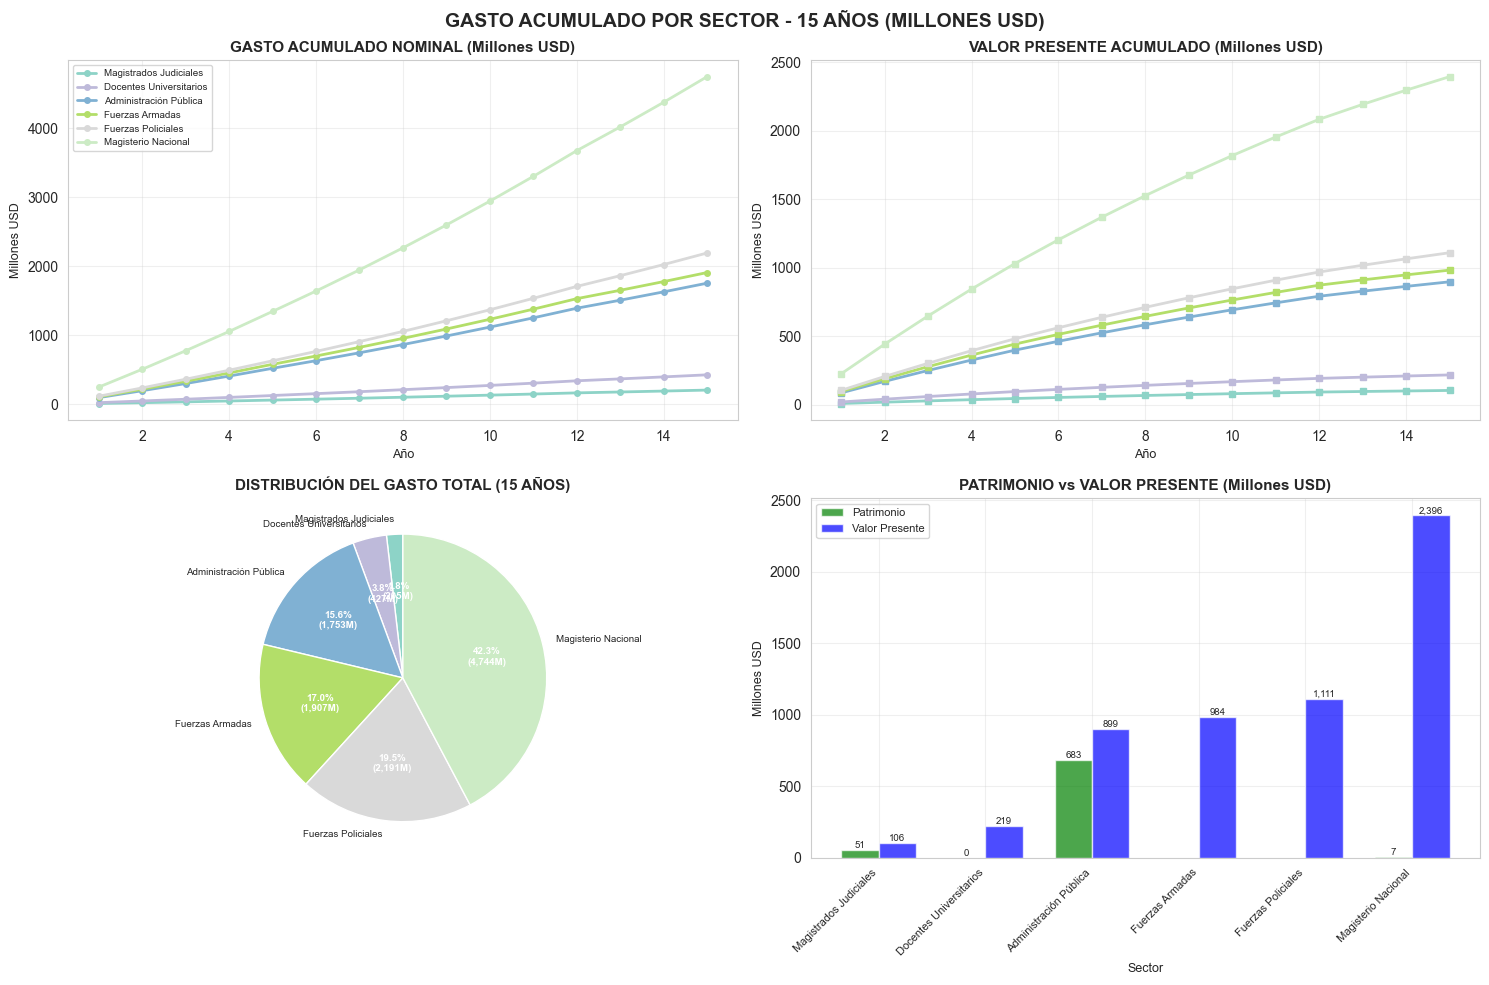


ANÁLISIS COMPARATIVO - EN DÓLARES

📊 RATIOS CLAVE:

💵 GASTO PROMEDIO POR JUBILADO (anual):
   • Magisterio Nacional: USD 7,277
   • Fuerzas Policiales: USD 12,343
   • Fuerzas Armadas: USD 12,516
   • Administración Pública: USD 5,777
   • Docentes Universitarios: USD 11,830
   • Magistrados Judiciales: USD 16,835

🏦 RELACIÓN PATRIMONIO/GASTO ANUAL (años cubiertos):
   • Magisterio Nacional: 0.0 años
   • Fuerzas Policiales: 0.0 años
   • Fuerzas Armadas: 0.0 años
   • Administración Pública: 7.1 años
   • Docentes Universitarios: 0.0 años
   • Magistrados Judiciales: 4.5 años

📈 IMPACTO DE LA INFLACIÓN (4% anual):
   • Magisterio Nacional: Gasto crece 80% en 15 años
   • Fuerzas Policiales: Gasto crece 80% en 15 años
   • Fuerzas Armadas: Gasto crece 80% en 15 años

🔍 SOSTENIBILIDAD DEL SISTEMA:
   • Patrimonio total: USD 741M
   • VP obligaciones 15a: USD 5,715M
   • Cobertura total: 13.0%
   ⚠️  Sistema insostenible (brecha: USD 4,973M)
   • Necesario aumentar: 671% más patrimonio


In [ ]:
def calcular_gasto_acumulado_sectores_usd(df, n_anios=15, tasa_descuento=0.092369, inflacion=0.04):
    """
    Calcula gasto acumulado por sector en 15 años - TODO EN DÓLARES
    """
    
    print("="*90)
    print("CÁLCULO DE GASTO ACUMULADO POR SECTOR (15 AÑOS) - EN DÓLARES")
    print("="*90)
    
    # ========================================================================
    # 1. PATRIMONIO POR SECTOR (USD) - DATOS EXACTOS DEL INFORME
    # ========================================================================
    
    patrimonio_usd_por_sector = {
        'Administración Pública': 682828175,
        'Magistrados Judiciales': 51040021,
        'Magisterio Nacional': 7024701,
        'Docentes Universitarios': 173828,
        'Fuerzas Armadas': 0,
        'Fuerzas Policiales': 0
    }
    
    # Tasa de cambio para conversiones
    tasa_cambio = 7278  # Gs/USD
    
    print(f"💰 TASA DE CAMBIO: Gs. {tasa_cambio:,.0f}/USD")
    print(f"💰 PATRIMONIO TOTAL SECTORES: USD {sum(patrimonio_usd_por_sector.values()):,.0f}")
    
    # ========================================================================
    # 2. TABLA DE MORTALIDAD
    # ========================================================================
    
    def probabilidad_vivo(edad, t, genero='H', anio_base=2024):
        """
        Probabilidad de estar vivo después de t años - Versión para Paraguay
        
        Args:
            edad: Edad actual en años
            t: Número de años futuros
            genero: 'H' para hombre, 'M' para mujer
            anio_base: Año base para proyecciones
        """
        if t <= 0:
            return 1.0
        
        # Tablas de mortalidad base RV-2015 ajustadas a Paraguay (por mil)
        if genero == 'H':  # Hombres Paraguay
            if edad < 25:
                qx_base = 1.0 / 1000  # 0.001
            elif edad < 35:
                qx_base = 1.6 / 1000  # 0.0016
            elif edad < 45:
                qx_base = 2.4 / 1000  # 0.0024
            elif edad < 55:
                qx_base = 4.5 / 1000  # 0.0045
            elif edad < 65:
                qx_base = 10.5 / 1000  # 0.0105
            elif edad < 75:
                qx_base = 25.4 / 1000  # 0.0254
            elif edad < 85:
                qx_base = 62.4 / 1000  # 0.0624
            else:
                qx_base = 154.0 / 1000  # 0.154
        else:  # Mujeres Paraguay
            if edad < 25:
                qx_base = 0.8 / 1000  # 0.0008
            elif edad < 35:
                qx_base = 1.2 / 1000  # 0.0012
            elif edad < 45:
                qx_base = 1.9 / 1000  # 0.0019
            elif edad < 55:
                qx_base = 3.2 / 1000  # 0.0032
            elif edad < 65:
                qx_base = 6.8 / 1000  # 0.0068
            elif edad < 75:
                qx_base = 16.3 / 1000  # 0.0163
            elif edad < 85:
                qx_base = 39.8 / 1000  # 0.0398
            else:
                qx_base = 98.0 / 1000  # 0.098
        
        # Factor de mejora por año (reducción del 1.5% anual en mortalidad)
        factor_mejora = 0.985
        
        # Probabilidad acumulada
        prob_acumulada = 1.0
        edad_actual = edad
        
        for i in range(t):
            # Mortalidad ajustada por edad y mejora en el tiempo
            qx_ajustado = qx_base * (factor_mejora ** i)
            
            # Ajuste adicional por envejecimiento (aumento de mortalidad con edad)
            # Factor aproximado de envejecimiento: 8-10% por año de edad
            factor_envejecimiento = 1.08 ** (i / 10)  # 8% cada 10 años
            
            qx_final = min(qx_ajustado * factor_envejecimiento, 0.99)  # Cap en 99%
            
            # Probabilidad de sobrevivir el año
            px = 1 - qx_final
            prob_acumulada *= px
            
            # Límite práctico
            if prob_acumulada < 0.0001:
                return 0.0
        
        return prob_acumulada

    
    # ========================================================================
    # 3. CÁLCULO DE GASTO EN DÓLARES
    # ========================================================================
    
    print(f"\n📊 CÁLCULO DE GASTO PARA {n_anios} AÑOS (EN USD)")
    print("-"*80)
    
    resultados = {}
    
    for sector in df['SECTOR'].unique():
        sector_data = df[df['SECTOR'] == sector]
        
        if len(sector_data) == 0:
            continue
        
        # Convertir montos iniciales a USD
        gasto_mensual_gs = sector_data['MONTO'].sum()
        gasto_mensual_usd = gasto_mensual_gs / tasa_cambio
        gasto_anual_usd = gasto_mensual_usd * 12
        
        print(f"\n🏢 {sector.upper()}:")
        print(f"   • Jubilados: {len(sector_data):,}")
        print(f"   • Gasto mensual: USD {gasto_mensual_usd:,.0f}")
        print(f"   • Gasto anual: USD {gasto_anual_usd:,.0f}")
        print(f"   • Patrimonio asignado: USD {patrimonio_usd_por_sector.get(sector, 0):,.0f}")
        
        # Inicializar arrays EN USD
        gasto_anual_usd_arr = np.zeros(n_anios)
        vivos_anual = np.zeros(n_anios)
        gasto_acumulado_usd = np.zeros(n_anios)
        vp_acumulado_usd = np.zeros(n_anios)
        
        # Calcular para cada jubilado
        for idx, jubilado in sector_data.iterrows():
            edad = jubilado['EDAD']
            monto_mensual_gs = jubilado['MONTO']
            monto_anual_usd = (monto_mensual_gs * 12) / tasa_cambio
            
            for t in range(n_anios):
                # Probabilidad de estar vivo
                prob = probabilidad_vivo(edad, t)
                
                # Si probabilidad > 0.5, considerar vivo
                if prob > 0.5:
                    # Gasto ajustado por inflación (en USD)
                    gasto = monto_anual_usd * ((1 + inflacion) ** t)
                    gasto_anual_usd_arr[t] += gasto
                    vivos_anual[t] += 1
        
        # Calcular acumulados y valor presente EN USD
        for t in range(n_anios):
            # Acumulado nominal
            if t == 0:
                gasto_acumulado_usd[t] = gasto_anual_usd_arr[t]
            else:
                gasto_acumulado_usd[t] = gasto_acumulado_usd[t-1] + gasto_anual_usd_arr[t]
            
            # Valor Presente acumulado
            vp_anual_usd = gasto_anual_usd_arr[t] / ((1 + tasa_descuento) ** (t + 1))
            if t == 0:
                vp_acumulado_usd[t] = vp_anual_usd
            else:
                vp_acumulado_usd[t] = vp_acumulado_usd[t-1] + vp_anual_usd
        
        # Almacenar resultados EN USD
        resultados[sector] = {
            'jubilados': len(sector_data),
            'gasto_anual_usd': gasto_anual_usd_arr,
            'gasto_acumulado_usd': gasto_acumulado_usd,
            'vp_acumulado_usd': vp_acumulado_usd,
            'vivos_anual': vivos_anual,
            'gasto_total_nominal_usd': np.sum(gasto_anual_usd_arr),
            'vp_total_usd': vp_acumulado_usd[-1] if len(vp_acumulado_usd) > 0 else 0,
            'patrimonio_usd': patrimonio_usd_por_sector.get(sector, 0),
            'gasto_mensual_usd': gasto_mensual_usd,
            'gasto_anual_inicial_usd': gasto_anual_usd
        }
        
        print(f"   • Gasto acumulado {n_anios}a: USD {gasto_acumulado_usd[-1]/1_000_000:,.1f}M")
        print(f"   • VP acumulado {n_anios}a: USD {vp_acumulado_usd[-1]/1_000_000:,.1f}M")
        print(f"   • Sobrevivientes finales: {vivos_anual[-1]:,.0f} ({vivos_anual[-1]/len(sector_data)*100:.1f}%)")
        
        # Calcular cobertura
        if vp_acumulado_usd[-1] > 0:
            cobertura = (patrimonio_usd_por_sector.get(sector, 0) / vp_acumulado_usd[-1] * 100)
            print(f"   • Cobertura patrimonio: {cobertura:.1f}%")
            
            if cobertura < 100:
                brecha = vp_acumulado_usd[-1] - patrimonio_usd_por_sector.get(sector, 0)
                print(f"   ⚠️  Brecha: USD {brecha/1_000_000:,.1f}M")
    
    # ========================================================================
    # 4. TABLA RESUMEN EN USD
    # ========================================================================
    
    print("\n" + "="*90)
    print("TABLA RESUMEN - TODO EN DÓLARES (MILLONES USD)")
    print("="*90)
    
    sectores_ordenados = sorted(resultados.keys(), 
                               key=lambda x: resultados[x]['gasto_total_nominal_usd'], 
                               reverse=True)
    
    print(f"\n{'SECTOR':<25} {'JUB':>6} {'GASTO/Anio':>12} {'GASTO 15A':>12} {'VP 15A':>12} {'PATRIM':>12} {'COB%':>8} {'BRECHA':>12}")
    print("-"*115)
    
    total_jubilados = 0
    total_gasto_15a_usd = 0
    total_vp_15a_usd = 0
    total_patrimonio_usd = 0
    total_brecha_usd = 0
    
    for sector in sectores_ordenados:
        datos = resultados[sector]
        
        jub = f"{datos['jubilados']:,.0f}"
        gasto_anio = f"{datos['gasto_anual_inicial_usd']/1_000_000:,.0f}M"
        gasto_15a = f"{datos['gasto_total_nominal_usd']/1_000_000:,.0f}M"
        vp_15a = f"{datos['vp_total_usd']/1_000_000:,.0f}M"
        patrim = f"{datos['patrimonio_usd']/1_000_000:,.0f}M"
        
        cobertura = (datos['patrimonio_usd'] / datos['vp_total_usd'] * 100) if datos['vp_total_usd'] > 0 else 0
        cob_str = f"{cobertura:.1f}%"
        
        brecha = max(0, datos['vp_total_usd'] - datos['patrimonio_usd'])
        brecha_str = f"{brecha/1_000_000:,.0f}M" if brecha > 0 else "0"
        
        print(f"{sector[:24]:<25} {jub:>6} {gasto_anio:>12} {gasto_15a:>12} {vp_15a:>12} "
              f"{patrim:>12} {cob_str:>8} {brecha_str:>12}")
        
        total_jubilados += datos['jubilados']
        total_gasto_15a_usd += datos['gasto_total_nominal_usd']
        total_vp_15a_usd += datos['vp_total_usd']
        total_patrimonio_usd += datos['patrimonio_usd']
        total_brecha_usd += brecha
    
    print("-"*115)
    
    # Totales
    total_cobertura = (total_patrimonio_usd / total_vp_15a_usd * 100) if total_vp_15a_usd > 0 else 0
    print(f"{'TOTAL':<25} {total_jubilados:>6,} {'':>12} {total_gasto_15a_usd/1_000_000:>11,.0f}M "
          f"{total_vp_15a_usd/1_000_000:>11,.0f}M {total_patrimonio_usd/1_000_000:>11,.0f}M "
          f"{total_cobertura:>7.1f}% {total_brecha_usd/1_000_000:>11,.0f}M")
    
    # ========================================================================
    # 5. GRÁFICOS EN USD
    # ========================================================================
    
    print(f"\n📈 GENERANDO GRÁFICOS EN DÓLARES...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'GASTO ACUMULADO POR SECTOR - {n_anios} AÑOS (MILLONES USD)', 
                 fontsize=14, fontweight='bold')
    
    # Colores por sector
    colores = plt.cm.Set3(np.arange(len(resultados)) / len(resultados))
    años = np.arange(1, n_anios + 1)
    
    # 1. GASTO ACUMULADO NOMINAL EN USD
    ax1 = axes[0, 0]
    for i, (sector, datos) in enumerate(resultados.items()):
        ax1.plot(años, datos['gasto_acumulado_usd'] / 1_000_000, 
                label=sector, color=colores[i], linewidth=2, marker='o', markersize=4)
    
    ax1.set_title('GASTO ACUMULADO NOMINAL (Millones USD)', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Año', fontsize=9)
    ax1.set_ylabel('Millones USD', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=7)
    
    # 2. VALOR PRESENTE ACUMULADO EN USD
    ax2 = axes[0, 1]
    for i, (sector, datos) in enumerate(resultados.items()):
        ax2.plot(años, datos['vp_acumulado_usd'] / 1_000_000, 
                label=sector, color=colores[i], linewidth=2, marker='s', markersize=4)
    
    ax2.set_title('VALOR PRESENTE ACUMULADO (Millones USD)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Año', fontsize=9)
    ax2.set_ylabel('Millones USD', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. DISTRIBUCIÓN DEL GASTO TOTAL
    ax3 = axes[1, 0]
    
    sectores = list(resultados.keys())
    gastos_totales = [resultados[s]['gasto_total_nominal_usd'] / 1_000_000 for s in sectores]
    
    wedges, texts, autotexts = ax3.pie(
        gastos_totales, 
        labels=sectores,
        autopct=lambda pct: f'{pct:.1f}%\n({pct*sum(gastos_totales)/100:,.0f}M)',
        colors=colores,
        startangle=90,
        textprops={'fontsize': 7}
    )
    
    ax3.set_title(f'DISTRIBUCIÓN DEL GASTO TOTAL ({n_anios} AÑOS)', fontsize=11, fontweight='bold')
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    # 4. COMPARACIÓN PATRIMONIO vs VP
    ax4 = axes[1, 1]
    
    patrimonio_vals = []
    vp_vals = []
    sectores_graf = []
    
    for sector in sectores:
        if resultados[sector]['patrimonio_usd'] > 0 or resultados[sector]['vp_total_usd'] > 0:
            patrimonio_vals.append(resultados[sector]['patrimonio_usd'] / 1_000_000)
            vp_vals.append(resultados[sector]['vp_total_usd'] / 1_000_000)
            sectores_graf.append(sector)
    
    x = np.arange(len(sectores_graf))
    width = 0.35
    
    bars1 = ax4.bar(x - width/2, patrimonio_vals, width, label='Patrimonio', color='green', alpha=0.7)
    bars2 = ax4.bar(x + width/2, vp_vals, width, label='Valor Presente', color='blue', alpha=0.7)
    
    ax4.set_title('PATRIMONIO vs VALOR PRESENTE (Millones USD)', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Sector', fontsize=9)
    ax4.set_ylabel('Millones USD', fontsize=9)
    ax4.set_xticks(x)
    ax4.set_xticklabels(sectores_graf, rotation=45, ha='right', fontsize=8)
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=8)
    
    # Agregar valores en las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0.1:  # Solo mostrar si es significativo
                ax4.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:,.0f}', ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    
    # Guardar gráficos
    plt.savefig('gasto_acumulado_sectores_usd.png', dpi=150, bbox_inches='tight')
    print(f"✓ Gráficos guardados como: 'gasto_acumulado_sectores_usd.png'")
    
    plt.show()
    
    # ========================================================================
    # 6. ANÁLISIS COMPARATIVO
    # ========================================================================
    
    print("\n" + "="*90)
    print("ANÁLISIS COMPARATIVO - EN DÓLARES")
    print("="*90)
    
    # Calcular ratios importantes
    print(f"\n📊 RATIOS CLAVE:")
    
    # 1. Gasto por jubilado
    print(f"\n💵 GASTO PROMEDIO POR JUBILADO (anual):")
    for sector in sectores_ordenados:
        datos = resultados[sector]
        gasto_por_jubilado = datos['gasto_anual_inicial_usd'] / datos['jubilados']
        print(f"   • {sector}: USD {gasto_por_jubilado:,.0f}")
    
    # 2. Relación patrimonio/gasto anual
    print(f"\n🏦 RELACIÓN PATRIMONIO/GASTO ANUAL (años cubiertos):")
    for sector in sectores_ordenados:
        datos = resultados[sector]
        if datos['gasto_anual_inicial_usd'] > 0:
            años_cubiertos = datos['patrimonio_usd'] / datos['gasto_anual_inicial_usd']
            print(f"   • {sector}: {años_cubiertos:.1f} años")
    
    # 3. Comparación con inflación
    print(f"\n📈 IMPACTO DE LA INFLACIÓN ({inflacion*100:.0f}% anual):")
    for sector in sectores_ordenados[:3]:  # Solo los 3 mayores
        datos = resultados[sector]
        crecimiento_nominal = ((1 + inflacion) ** n_anios - 1) * 100
        print(f"   • {sector}: Gasto crece {crecimiento_nominal:.0f}% en {n_anios} años")
    
    # 4. Sostenibilidad del sistema
    print(f"\n🔍 SOSTENIBILIDAD DEL SISTEMA:")
    print(f"   • Patrimonio total: USD {total_patrimonio_usd/1_000_000:,.0f}M")
    print(f"   • VP obligaciones 15a: USD {total_vp_15a_usd/1_000_000:,.0f}M")
    print(f"   • Cobertura total: {total_cobertura:.1f}%")
    
    if total_cobertura >= 100:
        print(f"   ✅ Sistema sostenible (excedente: USD {(total_patrimonio_usd - total_vp_15a_usd)/1_000_000:,.0f}M)")
    else:
        print(f"   ⚠️  Sistema insostenible (brecha: USD {total_brecha_usd/1_000_000:,.0f}M)")
        print(f"   • Necesario aumentar: {((100/total_cobertura)-1)*100:.0f}% más patrimonio")
        print(f"   • O reducir gastos en: {(1-total_cobertura/100)*100:.1f}%")
    
    # 5. Ranking de sectores por presión financiera
    print(f"\n🏆 RANKING POR PRESIÓN FINANCIERA (menor a mayor cobertura):")
    ranking = []
    for sector in resultados.keys():
        datos = resultados[sector]
        if datos['vp_total_usd'] > 0:
            cobertura = (datos['patrimonio_usd'] / datos['vp_total_usd'] * 100)
            ranking.append((sector, cobertura, datos['vp_total_usd']))
    
    ranking.sort(key=lambda x: x[1])  # Ordenar por cobertura (menor primero)
    
    for i, (sector, cobertura, vp) in enumerate(ranking, 1):
        status = "⚠️" if cobertura < 50 else "✅" if cobertura >= 100 else "🟡"
        print(f"   {i}. {status} {sector}: {cobertura:.1f}% (VP: USD {vp/1_000_000:,.0f}M)")
    
    return resultados

# ============================================================================
# EJECUTAR
# ============================================================================

if __name__ == "__main__":
    if 'df' in locals() and len(df) > 0:
        resultados_usd = calcular_gasto_acumulado_sectores_usd(df, n_anios=15)
    else:
        print("❌ Error: No se encontró el DataFrame 'df'")

In [ ]:
import pandas as pd
import locale
import chardet

# Configurar locale para formato de números
try:
    locale.setlocale(locale.LC_ALL, 'es_ES.UTF-8')
except:
    locale.setlocale(locale.LC_ALL, '')

# Función para detectar la codificación del archivo
def detect_encoding(file_path):
    with open(file_path, 'rb') as f:
        raw_data = f.read(10000)  # Lee los primeros 10KB para detectar
        result = chardet.detect(raw_data)
        return result['encoding']

# Detectar codificación del archivo
file_path = 'D:\ArchivosHDD\GitHub\jubilacionUNA\DatosJubilados2023\Bdd Jupe Jubilados Febrero 23.csv'
try:
    encoding = detect_encoding(file_path)
    print(f"Codificación detectada: {encoding}")
except:
    encoding = 'latin-1'  # Fallback a latin-1

# Lista de codificaciones a probar
encodings_to_try = [encoding, 'latin-1', 'cp1252', 'iso-8859-1', 'utf-8']

# Intentar cargar el archivo con diferentes codificaciones
df = None
for enc in encodings_to_try:
    try:
        print(f"Intentando cargar con codificación: {enc}")
        df = pd.read_csv(file_path, encoding=enc, on_bad_lines='skip')
        print(f"✓ Archivo cargado exitosamente con {enc}")
        break
    except Exception as e:
        print(f"✗ Error con {enc}: {str(e)[:100]}")

if df is None:
    print("No se pudo cargar el archivo con ninguna codificación. Intentando con engine='python'...")
    try:
        df = pd.read_csv(file_path, encoding='latin-1', sep=None, engine='python')
        print("✓ Archivo cargado con engine='python'")
    except Exception as e:
        print(f"Error crítico: {e}")
        exit(1)


# Mostrar las primeras filas para ver la estructura
print("Primeras 5 filas del dataset:")
print(df.head())
print("\n" + "="*80 + "\n")


Codificación detectada: ISO-8859-1
Intentando cargar con codificación: ISO-8859-1
✓ Archivo cargado exitosamente con ISO-8859-1
Primeras 5 filas del dataset:
  SECTOR    YEAR  MES  CEDULA  NRO_BENEF. FECHA_DECRETO NRO_DECRETO  % JUB  \
0  CIVIL  2023.0  2.0  352252    614818.0    2018/08/14      R-3782  100.0   
1  CIVIL  2023.0  2.0  335679    254933.0    1993/01/01         703   95.6   
2  CIVIL  2023.0  2.0  449533    629023.0    2020/12/11     RP-9545  100.0   
3  CIVIL  2023.0  2.0  248040    625625.0    2020/02/17      RP-937  100.0   
4  CIVIL  2023.0  2.0  233434    531066.0    2016/09/13      R-3898  100.0   

    F_INGRESO AÑOS APORTE  ...                                NOMBRES  \
0  2018/08/29          46  ...  PUCHETA VDA DE CORREA, ALICIA BEATRIZ   
1  2000/01/18          34  ...                        FRETES  ANTONIO   
2  2020/09/10          40  ...             RODRIGUEZ BAEZ, ANA ISABEL   
3  2020/03/09          49  ...           PEÑA CANDIA, MIRYAN JOSEFINA   
4  2016/

In [9]:
df.columns

Index(['SECTOR', 'YEAR', 'MES', 'CEDULA', 'NRO_BENEF.', 'FECHA_DECRETO',
       'NRO_DECRETO', '% JUB', 'F_INGRESO', 'AÑOS APORTE', 'YEAR_SERVICIO',
       'NOMBRES', 'F_NACIM.', 'CONCEPTO', 'CONCEPTO_NOMBRE', ' MONTO_MENSUAL ',
       ' CODIGO_JUBILADO ', 'NOMBRE_JUBILACION', 'OBJ_CODIGO', 'OBJETO_GASTO',
       'Unnamed: 20'],
      dtype='object')

In [10]:

# Ver las columnas disponibles
print("Columnas disponibles:")
print(df.columns.tolist())
print("\n" + "="*80 + "\n")

# Mapeo de códigos a sectores (basado en OBJETO_GASTO)
sector_mapping = {
    821: "Administración Pública",
    822: "Magistrados Judiciales",
    823: "Magisterio Nacional",
    824: "Docentes Universitarios",
    825: "Fuerzas Armadas",
    826: "Fuerzas Policiales"
}

# Limpiar la columna MONTO_MENSUAL (eliminar espacios y comas, convertir a float)
def clean_currency(value):
    if isinstance(value, str):
        # Eliminar espacios, comas y cualquier carácter no numérico excepto puntos
        cleaned = value.strip().replace(' ', '').replace(',', '')
        try:
            return float(cleaned)
        except:
            return 0.0
    return float(value)

df['MONTO_MENSUAL_CLEAN'] = df[' MONTO_MENSUAL '].apply(clean_currency)


Columnas disponibles:
['SECTOR', 'YEAR', 'MES', 'CEDULA', 'NRO_BENEF.', 'FECHA_DECRETO', 'NRO_DECRETO', '% JUB', 'F_INGRESO', 'AÑOS APORTE', 'YEAR_SERVICIO', 'NOMBRES', 'F_NACIM.', 'CONCEPTO', 'CONCEPTO_NOMBRE', ' MONTO_MENSUAL ', ' CODIGO_JUBILADO ', 'NOMBRE_JUBILACION', 'OBJ_CODIGO', 'OBJETO_GASTO', 'Unnamed: 20']




In [11]:

# Agrupar por OBJ_CODIGO y sumar los montos mensuales
gasto_mensual = df.groupby('OBJ_CODIGO')['MONTO_MENSUAL_CLEAN'].sum()

# Crear DataFrame con los resultados
resultados = pd.DataFrame({
    'Código': gasto_mensual.index,
    'Sector': [sector_mapping.get(cod, f'Desconocido ({cod})') for cod in gasto_mensual.index],
    'Gasto Mensual (Gs)': gasto_mensual.values,
    'Gasto Anual (Gs)': gasto_mensual.values * 12
})

# Ordenar por código
resultados = resultados.sort_values('Código')

# Calcular totales
total_mensual = resultados['Gasto Mensual (Gs)'].sum()
total_anual = total_mensual * 12

# Formatear números con separadores de miles
def format_currency(value):
    return locale.format_string("%.0f", value, grouping=True)

# Mostrar resultados
print("GASTO EN JUBILACIONES - FEBRERO 2023")
print("="*100)
print(f"{'SECTOR':<30} {'CÓDIGO':<8} {'MENSUAL (Gs)':<20} {'ANUAL (Gs)':<20}")
print("-"*100)

for _, row in resultados.iterrows():
    print(f"{row['Sector']:<30} {row['Código']:<8} {format_currency(row['Gasto Mensual (Gs)']):<20} {format_currency(row['Gasto Anual (Gs)']):<20}")

print("-"*100)
print(f"{'TOTAL':<30} {'':<8} {format_currency(total_mensual):<20} {format_currency(total_anual):<20}")
print("="*100)

# Mostrar en millones para mejor comparación
print("\n" + "="*80)
print("RESUMEN EN MILLONES DE GUARANÍES (Gs)")
print("="*80)
print(f"{'SECTOR':<30} {'MENSUAL (Mill. Gs)':<20} {'ANUAL (Mill. Gs)':<20}")
print("-"*80)

for _, row in resultados.iterrows():
    mensual_mill = row['Gasto Mensual (Gs)'] / 1_000_000
    anual_mill = row['Gasto Anual (Gs)'] / 1_000_000
    print(f"{row['Sector']:<30} {mensual_mill:>18.3f} {anual_mill:>19.3f}")

print("-"*80)
total_mensual_mill = total_mensual / 1_000_000
total_anual_mill = total_anual / 1_000_000
print(f"{'TOTAL':<30} {total_mensual_mill:>18.3f} {total_anual_mill:>19.3f}")

# Comparación con la tabla original (en millones de Gs.)
print("\n" + "="*100)
print("COMPARACIÓN CON TABLA ORIGINAL 2023 (en millones de Gs.)")
print("="*100)
print(f"{'SECTOR':<30} {'ORIGINAL (2023)':<20} {'CALCULADO (anual)':<20} {'DIFERENCIA':<20} {'% DIF':<10}")
print("-"*100)

# Valores originales de la tabla proporcionada
original_values = {
    "Administración Pública": 870743,
    "Magistrados Judiciales": 108.08,
    "Magisterio Nacional": 1913773,
    "Docentes Universitarios": 164802,
    "Fuerzas Armadas": 787957,
    "Fuerzas Policiales": 915686
}

for sector, original in original_values.items():
    # Buscar el sector calculado
    calculated_row = resultados[resultados['Sector'] == sector]
    if not calculated_row.empty:
        calculated = calculated_row['Gasto Anual (Gs)'].values[0] / 1_000_000
        diff = calculated - original
        pct_diff = (diff / original * 100) if original != 0 else 0
        
        print(f"{sector:<30} {original:>19.3f} {calculated:>19.3f} {diff:>19.3f} {pct_diff:>9.1f}%")
    else:
        print(f"{sector:<30} {original:>19.3f} {'No encontrado':>19} {'':>19} {'':>9}")

# Guardar resultados en un archivo CSV
resultados.to_csv('gasto_jubilaciones_2023.csv', index=False, encoding='utf-8')
print(f"\nResultados guardados en 'gasto_jubilaciones_2023.csv'")

# Estadísticas adicionales
print("\n" + "="*80)
print("ESTADÍSTICAS ADICIONALES")
print("="*80)
print(f"Número total de registros: {len(df)}")
print(f"Promedio mensual por jubilado: {format_currency(df['MONTO_MENSUAL_CLEAN'].mean())} Gs.")
print(f"Monto mensual máximo: {format_currency(df['MONTO_MENSUAL_CLEAN'].max())} Gs.")
print(f"Monto mensual mínimo: {format_currency(df['MONTO_MENSUAL_CLEAN'].min())} Gs.")

# Distribución por sector en porcentaje
print("\nDistribución porcentual por sector (mensual):")
for _, row in resultados.iterrows():
    porcentaje = (row['Gasto Mensual (Gs)'] / total_mensual) * 100
    print(f"  {row['Sector']}: {porcentaje:.2f}%")

GASTO EN JUBILACIONES - FEBRERO 2023
SECTOR                         CÓDIGO   MENSUAL (Gs)         ANUAL (Gs)          
----------------------------------------------------------------------------------------------------
Administración Pública         821.0    58.316.250.730       699.795.008.760     
Magistrados Judiciales         822.0    6.810.495.416        81.725.944.992      
Magisterio Nacional            823.0    150.547.947.189      1.806.575.366.268   
Docentes Universitarios        824.0    14.213.167.913       170.558.014.956     
Fuerzas Armadas                825.0    64.767.541.782       777.210.501.384     
Fuerzas Policiales             826.0    70.442.738.184       845.312.858.208     
----------------------------------------------------------------------------------------------------
TOTAL                                   365.098.141.214      4.381.177.694.568   

RESUMEN EN MILLONES DE GUARANÍES (Gs)
SECTOR                         MENSUAL (Mill. Gs)   ANUAL (Mill. G

In [4]:
import pandas as pd
import json

TASA_APORTE = 0.16
AÑO = 2023
MES = 2

# ===============================
# MAPEO DE SECTORES
# ===============================
SECTOR_MAPPING = {
    # Administración Pública
    0: "Administración Pública",
    111: "Administración Pública", 112: "Administración Pública",
    113: "Administración Pública", 114: "Administración Pública",
    115: "Administración Pública", 116: "Administración Pública",
    117: "Administración Pública", 118: "Administración Pública",
    119: "Administración Pública", 191: "Administración Pública",
    199: "Administración Pública", 841: "Administración Pública",

    # Magistrados
    123: "Magistrados Judiciales",
    125: "Magistrados Judiciales",
    232: "Magistrados Judiciales",
    239: "Magistrados Judiciales",

    # Magisterio
    131: "Magisterio Nacional",
    132: "Magisterio Nacional",
    133: "Magisterio Nacional",
    134: "Magisterio Nacional",
    135: "Magisterio Nacional",
    137: "Magisterio Nacional",
    138: "Magisterio Nacional",

    # Docentes universitarios
    141: "Docentes Universitarios",
    142: "Docentes Universitarios",
    144: "Docentes Universitarios",
    145: "Docentes Universitarios",
    148: "Docentes Universitarios",

    # FF.AA.
    151: "Fuerzas Armadas",
    152: "Fuerzas Armadas",
    153: "Fuerzas Armadas",
    154: "Fuerzas Armadas",
    155: "Fuerzas Armadas",

    # Policía
    161: "Fuerzas Policiales",
    162: "Fuerzas Policiales",
    163: "Fuerzas Policiales",
    164: "Fuerzas Policiales",
    165: "Fuerzas Policiales",
}

# ===============================
# 1. CARGAR CSV
# ===============================
df = pd.read_csv(
    "D:/ArchivosHDD/GitHub/jubilacionUNA/DatosJubilados2023/funcionarios_2023_2.csv",
    dtype=str,
    encoding="latin-1"
)

df.columns = df.columns.str.strip()

df["anho"] = pd.to_numeric(df["anho"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")
df["devengado"] = pd.to_numeric(df["devengado"], errors="coerce").fillna(0)
df["objeto_gasto"] = pd.to_numeric(df["objeto_gasto"], errors="coerce")

# Filtrar 2023-Febrero
df = df[(df["anho"] == AÑO) & (df["mes"] == MES)].copy()

# ===============================
# 2. ASIGNAR SECTOR
# ===============================
df["sector"] = df["objeto_gasto"].map(SECTOR_MAPPING)
df["sector"] = df["sector"].fillna("Administración Pública")

# ===============================
# 3. CALCULAR APORTES 2023
# ===============================
df["aporte_anual"] = df["devengado"] * TASA_APORTE * 12

resumen_2023 = (
    df.groupby("sector", as_index=False)
      .agg(
          salario_anual_mill=("devengado", lambda x: x.sum() * 12 / 1_000_000),
          aporte_anual_mill=("aporte_anual", lambda x: x.sum() / 1_000_000),
          registros=("sector", "size")
      )
      .sort_values("aporte_anual_mill", ascending=False)
)

print("\nAPORTES CALCULADOS 2023 (millones Gs)")
print(resumen_2023.round(2))

# ===============================
# 4. CARGAR JSON PUBLICADO
# ===============================
with open("ingresos_publicados_2023.json", encoding="utf-8") as f:
    publicados = json.load(f)

df_publicado = pd.DataFrame(publicados)

# esperado:
# sector | aporte_2023_mill

# ===============================
# 5. COMPARAR
# ===============================
comparacion = resumen_2023.merge(
    df_publicado,
    on="sector",
    how="left"
)

comparacion["diferencia_mill"] = (
    comparacion["aporte_anual_mill"] - comparacion["aporte_2023_mill"]
)

comparacion["dif_pct"] = (
    comparacion["diferencia_mill"] / comparacion["aporte_2023_mill"] * 100
)

print("\nCOMPARACIÓN 2023 – CALCULADO vs PUBLICADO")
print(
    comparacion[
        ["sector", "aporte_anual_mill", "aporte_2023_mill", "diferencia_mill", "dif_pct"]
    ].round(2)
)

# ===============================
# 6. GUARDAR RESULTADO
# ===============================
comparacion.to_csv(
    "comparacion_aportes_2023.csv",
    index=False,
    encoding="utf-8"
)

print("\n✓ Archivo guardado: comparacion_aportes_2023.csv")



APORTES CALCULADOS 2023 (millones Gs)
                    sector  salario_anual_mill  aporte_anual_mill  registros
0   Administración Pública         16434987.20         2629597.95     557039
1  Docentes Universitarios          3694379.93          591100.79     132110
3      Magisterio Nacional          2684186.36          429469.82     293763
4   Magistrados Judiciales           377843.90           60455.02      31448
2       Fuerzas Policiales           176733.93           28277.43        415

COMPARACIÓN 2023 – CALCULADO vs PUBLICADO
                    sector  aporte_anual_mill  aporte_2023_mill  \
0   Administración Pública         2629597.95           1603068   
1  Docentes Universitarios          591100.79            161183   
2      Magisterio Nacional          429469.82           1176179   
3   Magistrados Judiciales           60455.02            131326   
4       Fuerzas Policiales           28277.43            340251   

   diferencia_mill  dif_pct  
0       1026529.95    6